In [19]:
import openpyxl
from openpyxl.utils import get_column_letter
import bisect
import sys

def read_group_data(sheet, start_col):
    """读取两列组成的数据组"""
    # 检查第一行温度值
    temp1 = sheet.cell(row=1, column=start_col).value
    temp2 = sheet.cell(row=1, column=start_col+1).value
    
    try:
        temp1 = float(temp1)
        temp2 = float(temp2)
    except TypeError:
        print(f"错误：第{start_col}和{start_col+1}列的温度值不是有效数字")
        sys.exit(1)
    
    if abs(temp1 - temp2) > 1e-6:  # 允许浮点数微小误差
        print(f"错误：第{start_col}列温度{temp1}与第{start_col+1}列温度{temp2}不相等")
        sys.exit(1)
    
    temperature = round((temp1 + temp2) / 2, 2)  # 取平均值并保留两位小数
    
    # 读取数据
    time_data = []
    weight_data = []
    row = 3
    while True:
        time_val = sheet.cell(row=row, column=start_col).value
        weight_val = sheet.cell(row=row, column=start_col+1).value
        
        if time_val is None and weight_val is None:
            break
        
        try:
            time_data.append(float(time_val))
            weight_data.append(float(weight_val))
        except TypeError:
            break  # 遇到空值停止读取
        
        row += 1
    
    return {
        'temp': temperature,
        'time': time_data,
        'weight': weight_data,
        'length': len(time_data)
    }

# 读取原始数据
wb = openpyxl.load_workbook('x1.xlsx')
sheet1 = wb['Sheet1']

# 解析所有数据组
original_groups = []
max_col = sheet1.max_column

for col in range(1, max_col, 2):
    if col+1 > max_col:
        break
    group_data = read_group_data(sheet1, col)
    original_groups.append(group_data)

# 按温度排序原始数据
original_groups.sort(key=lambda x: x['temp'])
temps = [g['temp'] for g in original_groups]

# 生成目标温度列表
target_temps = [t for t in range(-180, 2301, 10)]

# 数据增强处理
enhanced_data = []
for target_temp in target_temps:
    # 寻找相邻温度索引
    idx = bisect.bisect_left(temps, target_temp)
    
    # 边界情况处理
    if idx == 0:
        if target_temp < temps[0]:
            continue  # 忽略低于最小温度的数据
        else:
            prev = original_groups[0]
            next = original_groups[0]
    elif idx == len(temps):
        prev = original_groups[-1]
        next = original_groups[-1]
    else:
        prev = original_groups[idx-1]
        next = original_groups[idx]
    
    # 确定有效长度
    valid_length = min(prev['length'], next['length'])
    
    # 当目标温度已存在时直接使用现有数据
    if abs(prev['temp'] - target_temp) < 1e-6:
        enhanced_data.append({
            'temp': target_temp,
            'time': prev['time'][:valid_length],
            'weight': prev['weight'][:valid_length]
        })
        continue
    
    # 线性插值处理
    interpolated = []
    for i in range(valid_length):
        ratio = (target_temp - prev['temp']) / (next['temp'] - prev['temp'])
        w = prev['weight'][i] + ratio * (next['weight'][i] - prev['weight'][i])
        interpolated.append(w)
    
    enhanced_data.append({
        'temp': target_temp,
        'time': prev['time'][:valid_length],  # 使用前一个温度的时间序列
        'weight': interpolated
    })

# 处理输出工作表
if 'Sheet2' in wb.sheetnames:
    wb.remove(wb['Sheet2'])
sheet2 = wb.create_sheet('Sheet2', 0)  # 创建在首位

# 写入增强数据
current_col = 1
for data in enhanced_data:
    # 写入温度（合并单元格）
    sheet2.merge_cells(
        start_row=1, start_column=current_col,
        end_row=1, end_column=current_col+1
    )
    sheet2.cell(1, current_col, data['temp'])
    
    # 写表头
    sheet2.cell(2, current_col, '时间')
    sheet2.cell(2, current_col+1, '重量')
    
    # 写数据
    for i in range(len(data['time'])):
        sheet2.cell(i+3, current_col, data['time'][i])
        sheet2.cell(i+3, current_col+1, data['weight'][i])
    
    current_col += 2

# 保存文件
wb.save('x1.xlsx')
print("数据处理完成，结果已保存到Sheet2")

数据处理完成，结果已保存到Sheet2


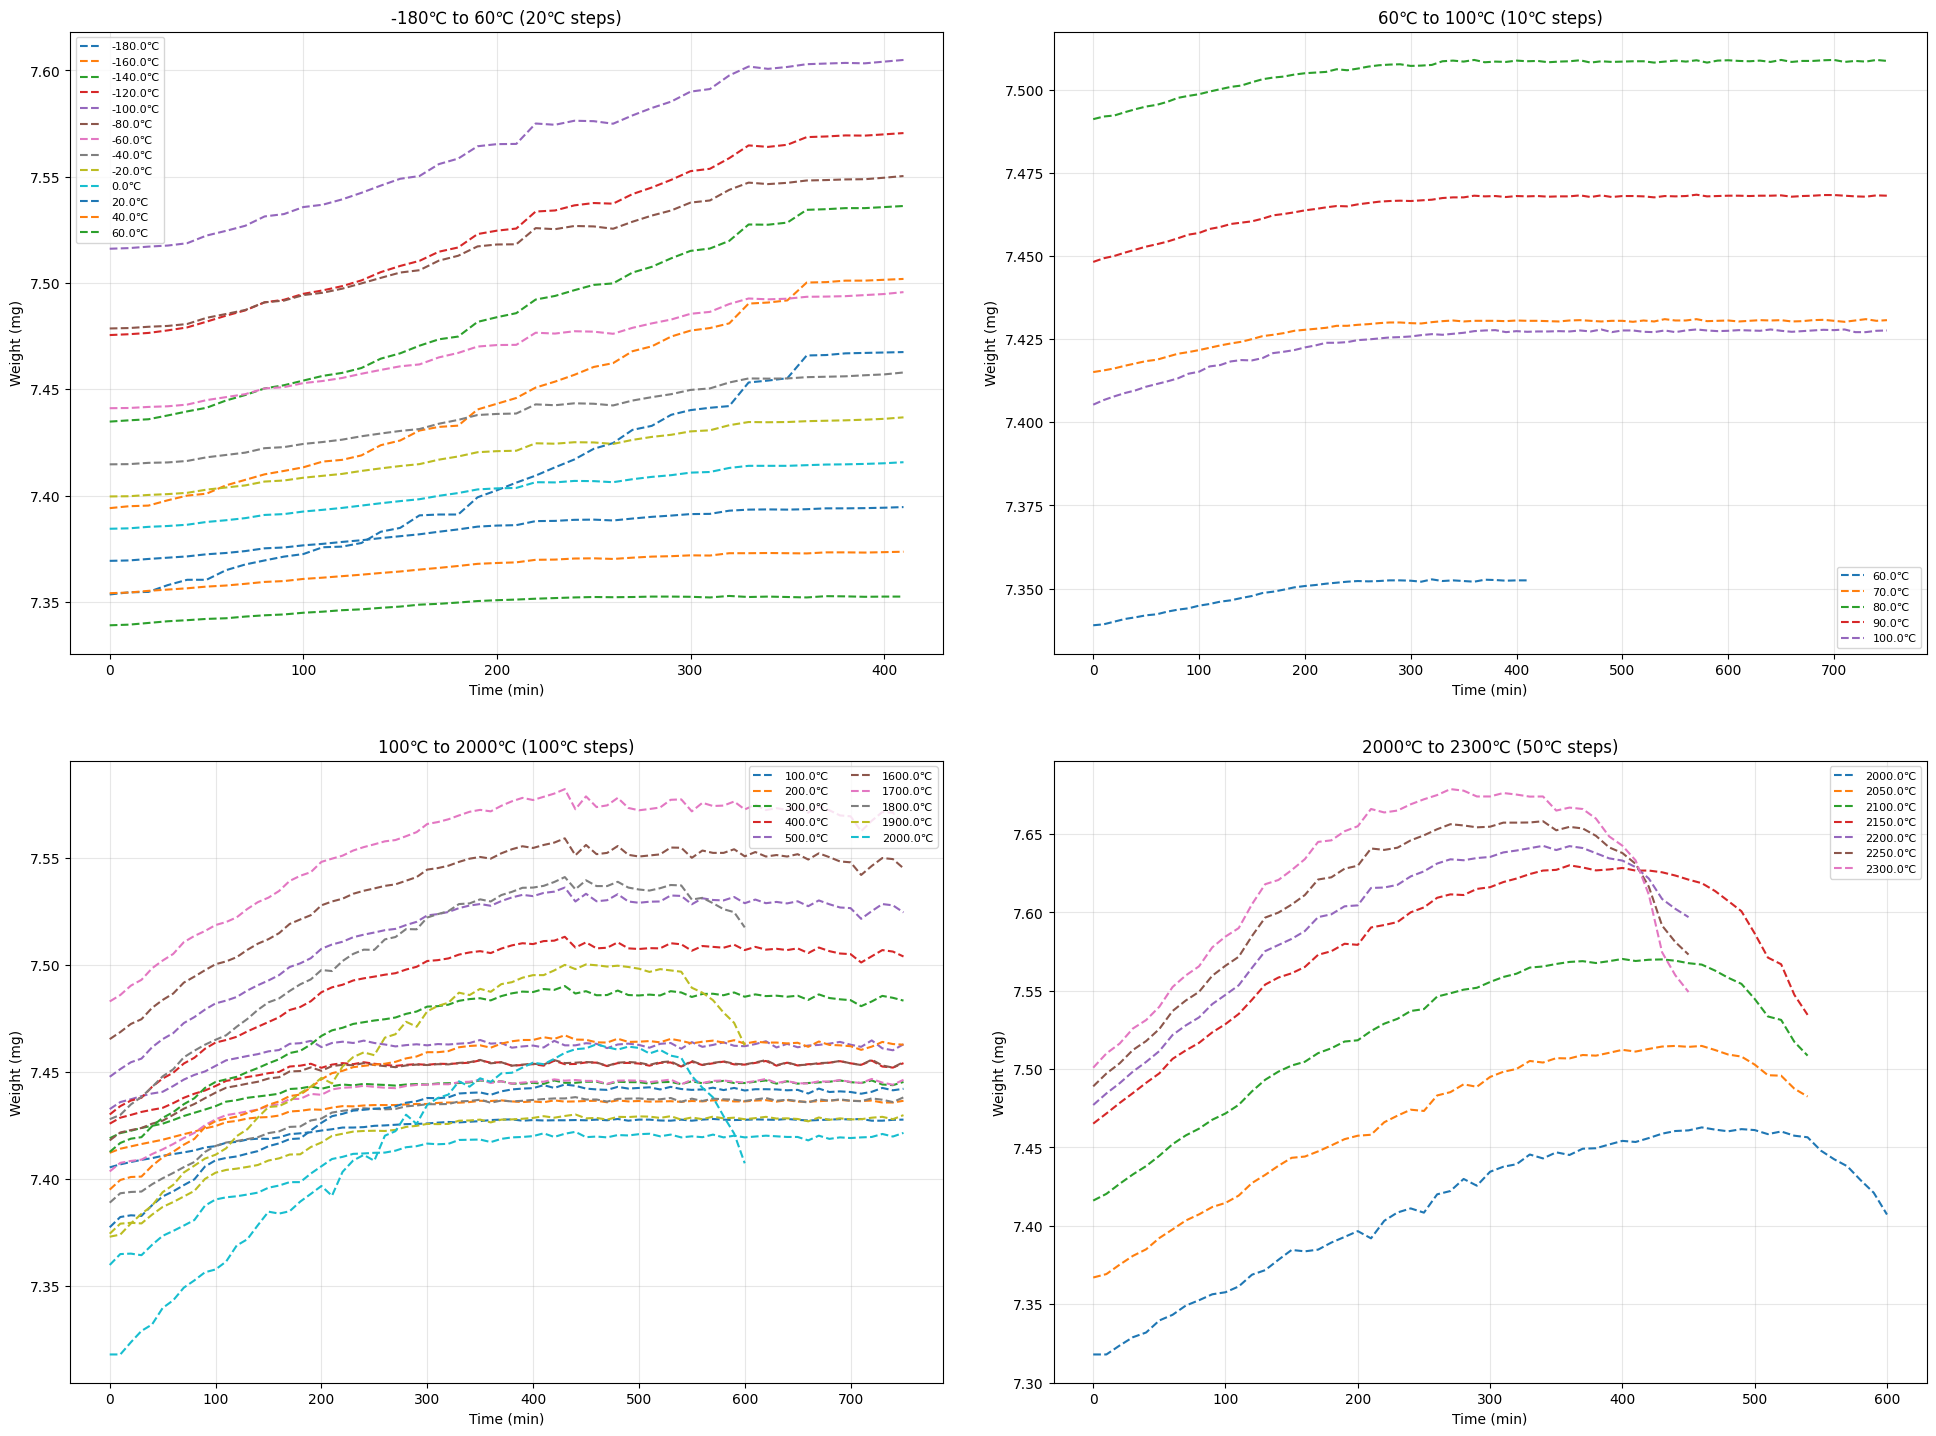

In [21]:
import openpyxl
import matplotlib.pyplot as plt
from openpyxl.utils import get_column_letter

# 读取原始温度数据
def get_original_temps(sheet):
    original_temps = set()
    current_col = 1
    
    while current_col <= sheet.max_column:
        # 检查合并单元格
        merged = False
        for merge_range in sheet.merged_cells.ranges:
            if merge_range.min_row == 1 and merge_range.max_row == 1:
                if merge_range.min_col == current_col:
                    temp = sheet.cell(1, current_col).value
                    try:
                        original_temps.add(round(float(temp), 2))
                    except:
                        pass
                    current_col = merge_range.max_col + 1
                    merged = True
                    break
        if not merged:
            current_col += 1
    
    return original_temps

# 读取Sheet2数据
def read_sheet2_data(sheet, original_temps):
    data_groups = []
    current_col = 1
    
    while current_col <= sheet.max_column:
        # 读取温度
        try:
            temp = round(float(sheet.cell(1, current_col).value), 2)
        except:
            current_col += 2
            continue
        
        # 判断是否原始数据
        is_original = any(abs(temp - t) < 0.01 for t in original_temps)
        
        # 读取数据
        time_data = []
        weight_data = []
        row = 3
        while True:
            time_val = sheet.cell(row, current_col).value
            weight_val = sheet.cell(row, current_col+1).value
            if time_val is None or weight_val is None:
                break
            try:
                time_data.append(float(time_val))
                weight_data.append(float(weight_val))
            except:
                break
            row += 1
        
        data_groups.append({
            'temp': temp,
            'time': time_data,
            'weight': weight_data,
            'is_original': is_original
        })
        current_col += 2
    
    return data_groups

# 主程序
wb = openpyxl.load_workbook('x1.xlsx')

# 获取原始温度
sheet1 = wb['Sheet1']
original_temps = get_original_temps(sheet1)

# 读取Sheet2数据
sheet2 = wb['Sheet2']
all_data = read_sheet2_data(sheet2, original_temps)

# 定义图表配置
chart_configs = [
    {'range': (-180, 60), 'step': 20, 'axes': [0, 0], 'title': '-180℃ to 60℃ (20℃ steps)'},
    {'range': (60, 100), 'step': 10, 'axes': [0, 1], 'title': '60℃ to 100℃ (10℃ steps)'},
    {'range': (100, 2000), 'step': 100, 'axes': [1, 0], 'title': '100℃ to 2000℃ (100℃ steps)'},
    {'range': (2000, 2300), 'step': 50, 'axes': [1, 1], 'title': '2000℃ to 2300℃ (50℃ steps)'}
]

# 创建画布
plt.figure(figsize=(20, 15))

# 生成每个子图
for config in chart_configs:
    # 生成目标温度列表
    start, end = config['range']
    target_temps = list(range(start, end + config['step'], config['step']))
    
    # 筛选数据
    filtered_data = []
    for temp in target_temps:
        # 寻找最接近的温度数据
        closest = None
        min_diff = float('inf')
        for data in all_data:
            diff = abs(data['temp'] - temp)
            if diff < min_diff:
                min_diff = diff
                closest = data
        
        if min_diff < 0.1:  # 允许0.1℃的误差
            filtered_data.append(closest)
    
    # 创建子图
    ax = plt.subplot2grid((2, 2), config['axes'])
    
    # 绘制曲线
    for data in filtered_data:
        linestyle = '-' if data['is_original'] else '--'
        ax.plot(data['time'], data['weight'], 
                linestyle=linestyle,
                linewidth=1.5,
                label=f"{data['temp']}℃")
    
    # 图表装饰
    ax.set_title(config['title'])
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Weight (mg)')
    ax.grid(True, alpha=0.3)
    
    # 智能图例显示
    handles, labels = ax.get_legend_handles_labels()
    if len(labels) > 15:  # 只显示首尾各5条
        ax.legend(handles[:5] + handles[-5:],
                 labels[:5] + labels[-5:],
                 loc='upper right',
                 fontsize=8,
                 ncol=2)
    else:
        ax.legend(loc='best', fontsize=8)

plt.tight_layout(pad=3.0)
plt.savefig('Thermal_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
from openpyxl import load_workbook

# 加载工作簿
wb = load_workbook("x1.xlsx")
ws = wb["Sheet3"]

# 获取所有合并单元格区域（仅第一行且跨2列）
merged_ranges = [
    merge for merge in ws.merged_cells.ranges
    if merge.min_row == 1 
    and (merge.max_col - merge.min_col + 1) == 2
]

if not merged_ranges:
    print("第一行没有合并单元格")
    exit()

# 改为从左向右排序（关键修改点）
merged_ranges.sort(key=lambda x: x.min_col)  # 按最小列升序排列

# 遍历处理合并单元格
for merge in merged_ranges:
    # 获取合并单元格值
    cell_value = ws.cell(row=1, column=merge.min_col).value
    print(f"正在处理值：{cell_value}")
    
    # 拆分单元格并填充
    ws.unmerge_cells(str(merge))
    ws.cell(1, merge.min_col, cell_value)
    ws.cell(1, merge.min_col+1, cell_value)
    
    # 终止条件检查
    if cell_value == 2300:
        print("找到2300，停止处理")
        break  # 立即终止循环

# 保存修改
try:
    wb.save("x1.xlsx")
    print("文件已保存")
except Exception as e:
    print(f"保存失败！错误：{str(e)}")
finally:
    wb.close()

正在处理值：-180
正在处理值：-170
正在处理值：-160
正在处理值：-150
正在处理值：-140
正在处理值：-130
正在处理值：-120
正在处理值：-110
正在处理值：-100
正在处理值：-90
正在处理值：-80
正在处理值：-70
正在处理值：-60
正在处理值：-50
正在处理值：-40
正在处理值：-30
正在处理值：-20
正在处理值：-10
正在处理值：0
正在处理值：10
正在处理值：20
正在处理值：30
正在处理值：40
正在处理值：50
正在处理值：60
正在处理值：70
正在处理值：80
正在处理值：90
正在处理值：100
正在处理值：110
正在处理值：120
正在处理值：130
正在处理值：140
正在处理值：150
正在处理值：160
正在处理值：170
正在处理值：180
正在处理值：190
正在处理值：200
正在处理值：210
正在处理值：220
正在处理值：230
正在处理值：240
正在处理值：250
正在处理值：260
正在处理值：270
正在处理值：280
正在处理值：290
正在处理值：300
正在处理值：310
正在处理值：320
正在处理值：330
正在处理值：340
正在处理值：350
正在处理值：360
正在处理值：370
正在处理值：380
正在处理值：390
正在处理值：400
正在处理值：410
正在处理值：420
正在处理值：430
正在处理值：440
正在处理值：450
正在处理值：460
正在处理值：470
正在处理值：480
正在处理值：490
正在处理值：500
正在处理值：510
正在处理值：520
正在处理值：530
正在处理值：540
正在处理值：550
正在处理值：560
正在处理值：570
正在处理值：580
正在处理值：590
正在处理值：600
正在处理值：610
正在处理值：620
正在处理值：630
正在处理值：640
正在处理值：650
正在处理值：660
正在处理值：670
正在处理值：680
正在处理值：690
正在处理值：700
正在处理值：710
正在处理值：720
正在处理值：730
正在处理值：740
正在处理值：750
正在处理值：760
正在处理值：770
正在处理值：780
正在处理值：790
正在处理值：800
正在处理值：810
正在

In [ ]:
from openpyxl import load_workbook

# 加载工作簿（启用data_only以获取计算后的值）
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet3"]

stop_flag = False  # 全局停止标志

# 遍历所有偶数列（从左到右）
for col in range(2, ws.max_column + 1, 2):
    # 获取列信息
    col_letter = ws.cell(row=1, column=col).column_letter
    first_val = ws.cell(row=1, column=col).value
    
    # 打印前三行信息
    print(f"\n处理列 {col_letter}：")
    print(f"[首行] {ws.cell(row=1, column=col).value}")
    print(f"[二行] {ws.cell(row=2, column=col).value}")
    print(f"[三行] {ws.cell(row=3, column=col).value}")
    
    # 获取初始重量
    try:
        initial_weight = float(ws.cell(row=3, column=col).value)
    except (TypeError, ValueError):
        print(f"! 第三行不是有效数字，跳过本列")
        continue
    
    # 处理数据行
    blank_counter = 0
    for row in range(4, ws.max_row + 1):
        cell = ws.cell(row=row, column=col)
        
        # 检测连续空白
        if cell.value is None:
            blank_counter += 1
            if blank_counter >= 3:
                print(f"! 检测到连续3个空白行，停止本列处理")
                break
            continue
        else:
            blank_counter = 0  # 重置计数器
            
        # 计算差值
        try:
            current_value = float(cell.value)
            new_value = current_value - initial_weight
            cell.value = new_value
            print(f"行 {row} 更新：{current_value} → {new_value:.6f}")
        except ValueError:
            print(f"! 行 {row} 包含非数字值，保留原值")
    
    # 检查停止条件
    if first_val == 2300:
        print(">>> 发现2300标志，处理完当前列后终止")
        stop_flag = True
        break

# 保存并关闭
wb.save("x1.xlsx")
wb.close()
print("\n处理完成，文件已保存")


处理列 B：
[首行] -180
[二行] 重量
[三行] 7.3535
行 4 更新：7.3545 → 0.00
行 5 更新：7.3547 → 0.00
行 6 更新：7.3579 → 0.00
行 7 更新：7.3604 → 0.01
行 8 更新：7.3604 → 0.01
行 9 更新：7.3649 → 0.01
行 10 更新：7.3676 → 0.01
行 11 更新：7.3695 → 0.02
行 12 更新：7.3713 → 0.02
行 13 更新：7.3725 → 0.02
行 14 更新：7.3757 → 0.02
行 15 更新：7.376 → 0.02
行 16 更新：7.3777 → 0.02
行 17 更新：7.383 → 0.03
行 18 更新：7.3848 → 0.03
行 19 更新：7.3907 → 0.04
行 20 更新：7.3911 → 0.04
行 21 更新：7.3911 → 0.04
行 22 更新：7.3992 → 0.05
行 23 更新：7.4025 → 0.05
行 24 更新：7.4061 → 0.05
行 25 更新：7.4094 → 0.06
行 26 更新：7.4133 → 0.06
行 27 更新：7.417 → 0.06
行 28 更新：7.422 → 0.07
行 29 更新：7.4247 → 0.07
行 30 更新：7.4309 → 0.08
行 31 更新：7.4328 → 0.08
行 32 更新：7.438 → 0.08
行 33 更新：7.4402 → 0.09
行 34 更新：7.4413 → 0.09
行 35 更新：7.4421 → 0.09
行 36 更新：7.4532 → 0.10
行 37 更新：7.4541 → 0.10
行 38 更新：7.4552 → 0.10
行 39 更新：7.4659 → 0.11
行 40 更新：7.4661 → 0.11
行 41 更新：7.4669 → 0.11
行 42 更新：7.4671 → 0.11
行 43 更新：7.4673 → 0.11
行 44 更新：7.4675 → 0.11
! 检测到连续3个空白行，停止本列处理

处理列 D：
[首行] -170
[二行] 重量
[三行] 7.3738
行 4 更新：7.3747

In [1]:
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

# 加载工作簿
wb = load_workbook("x1.xlsx")

# 删除已存在的Sheet4（如果存在）
if "Sheet4" in wb.sheetnames:
    del wb["Sheet4"]

# 复制Sheet3到Sheet4
source = wb["Sheet3"]
target = wb.create_sheet("Sheet4")
for row in source.iter_rows():
    for cell in row:
        target[cell.coordinate].value = cell.value

# 处理Sheet4
ws = wb["Sheet4"]
stop_flag = False

# 遍历偶数列（从左到右）
for col in range(2, ws.max_column + 1, 2):
    col_letter = get_column_letter(col)
    
    # 获取首行值
    first_row_value = ws.cell(row=1, column=col).value
    
    # 输出前三行信息
    print(f"\n处理列 {col_letter}:")
    for r in range(1, 4):
        cell_value = ws.cell(row=r, column=col).value
        print(f"第{r}行值: {cell_value if cell_value is not None else '空'}")

    # 获取初始重量
    try:
        initial_weight = float(ws.cell(row=3, column=col).value)
        print(f"初始重量: {initial_weight:.6f}")
    except (TypeError, ValueError):
        print("! 第三行无效，跳过本列")
        continue

    # 处理后续数据行
    blank_counter = 0
    for row in range(4, ws.max_row + 1):
        cell = ws.cell(row=row, column=col)
        
        # 检查连续空白
        if cell.value is None:
            blank_counter += 1
            if blank_counter >= 3:
                print(f"! 行{row-2}-{row}连续空白，停止本列处理")
                break
            continue
        else:
            blank_counter = 0

        # 计算新值
        try:
            original_value = float(cell.value)
            new_value = original_value / initial_weight
            cell.value = round(new_value, 6)  # 保留6位小数
            print(f"行{row}: {original_value} → {new_value:.6f}")
        except (TypeError, ValueError):
            print(f"! 行{row}包含非数字值: {cell.value}")

    # 检查停止条件
    if first_row_value == 2300:
        print(">>> 发现终止标志2300，停止运行")
        stop_flag = True
        break

# 保存修改
try:
    wb.save("x1.xlsx")
    print("\n文件保存成功")
except Exception as e:
    print(f"\n保存失败！错误信息: {str(e)}")
finally:
    wb.close()


处理列 B:
第1行值: -180
第2行值: 重量
第3行值: 7.3535
初始重量: 7.353500
行4: 0.0009999999999994458 → 0.000136
行5: 0.001199999999999868 → 0.000163
行6: 0.004399999999999515 → 0.000598
行7: 0.006899999999999906 → 0.000938
行8: 0.006899999999999906 → 0.000938
行9: 0.01139999999999919 → 0.001550
行10: 0.0141 → 0.001917
行11: 0.01600000000000001 → 0.002176
行12: 0.01779999999999937 → 0.002421
行13: 0.01899999999999924 → 0.002584
行14: 0.02219999999999978 → 0.003019
行15: 0.02249999999999996 → 0.003060
行16: 0.02419999999999956 → 0.003291
行17: 0.02949999999999964 → 0.004012
行18: 0.03129999999999988 → 0.004256
行19: 0.03719999999999946 → 0.005059
行20: 0.03759999999999941 → 0.005113
行21: 0.03759999999999941 → 0.005113
行22: 0.04570000000000007 → 0.006215
行23: 0.04899999999999949 → 0.006663
行24: 0.05259999999999998 → 0.007153
行25: 0.05589999999999939 → 0.007602
行26: 0.05979999999999919 → 0.008132
行27: 0.06349999999999945 → 0.008635
行28: 0.06849999999999934 → 0.009315
行29: 0.07119999999999926 → 0.009682
行30: 0.07739999999999

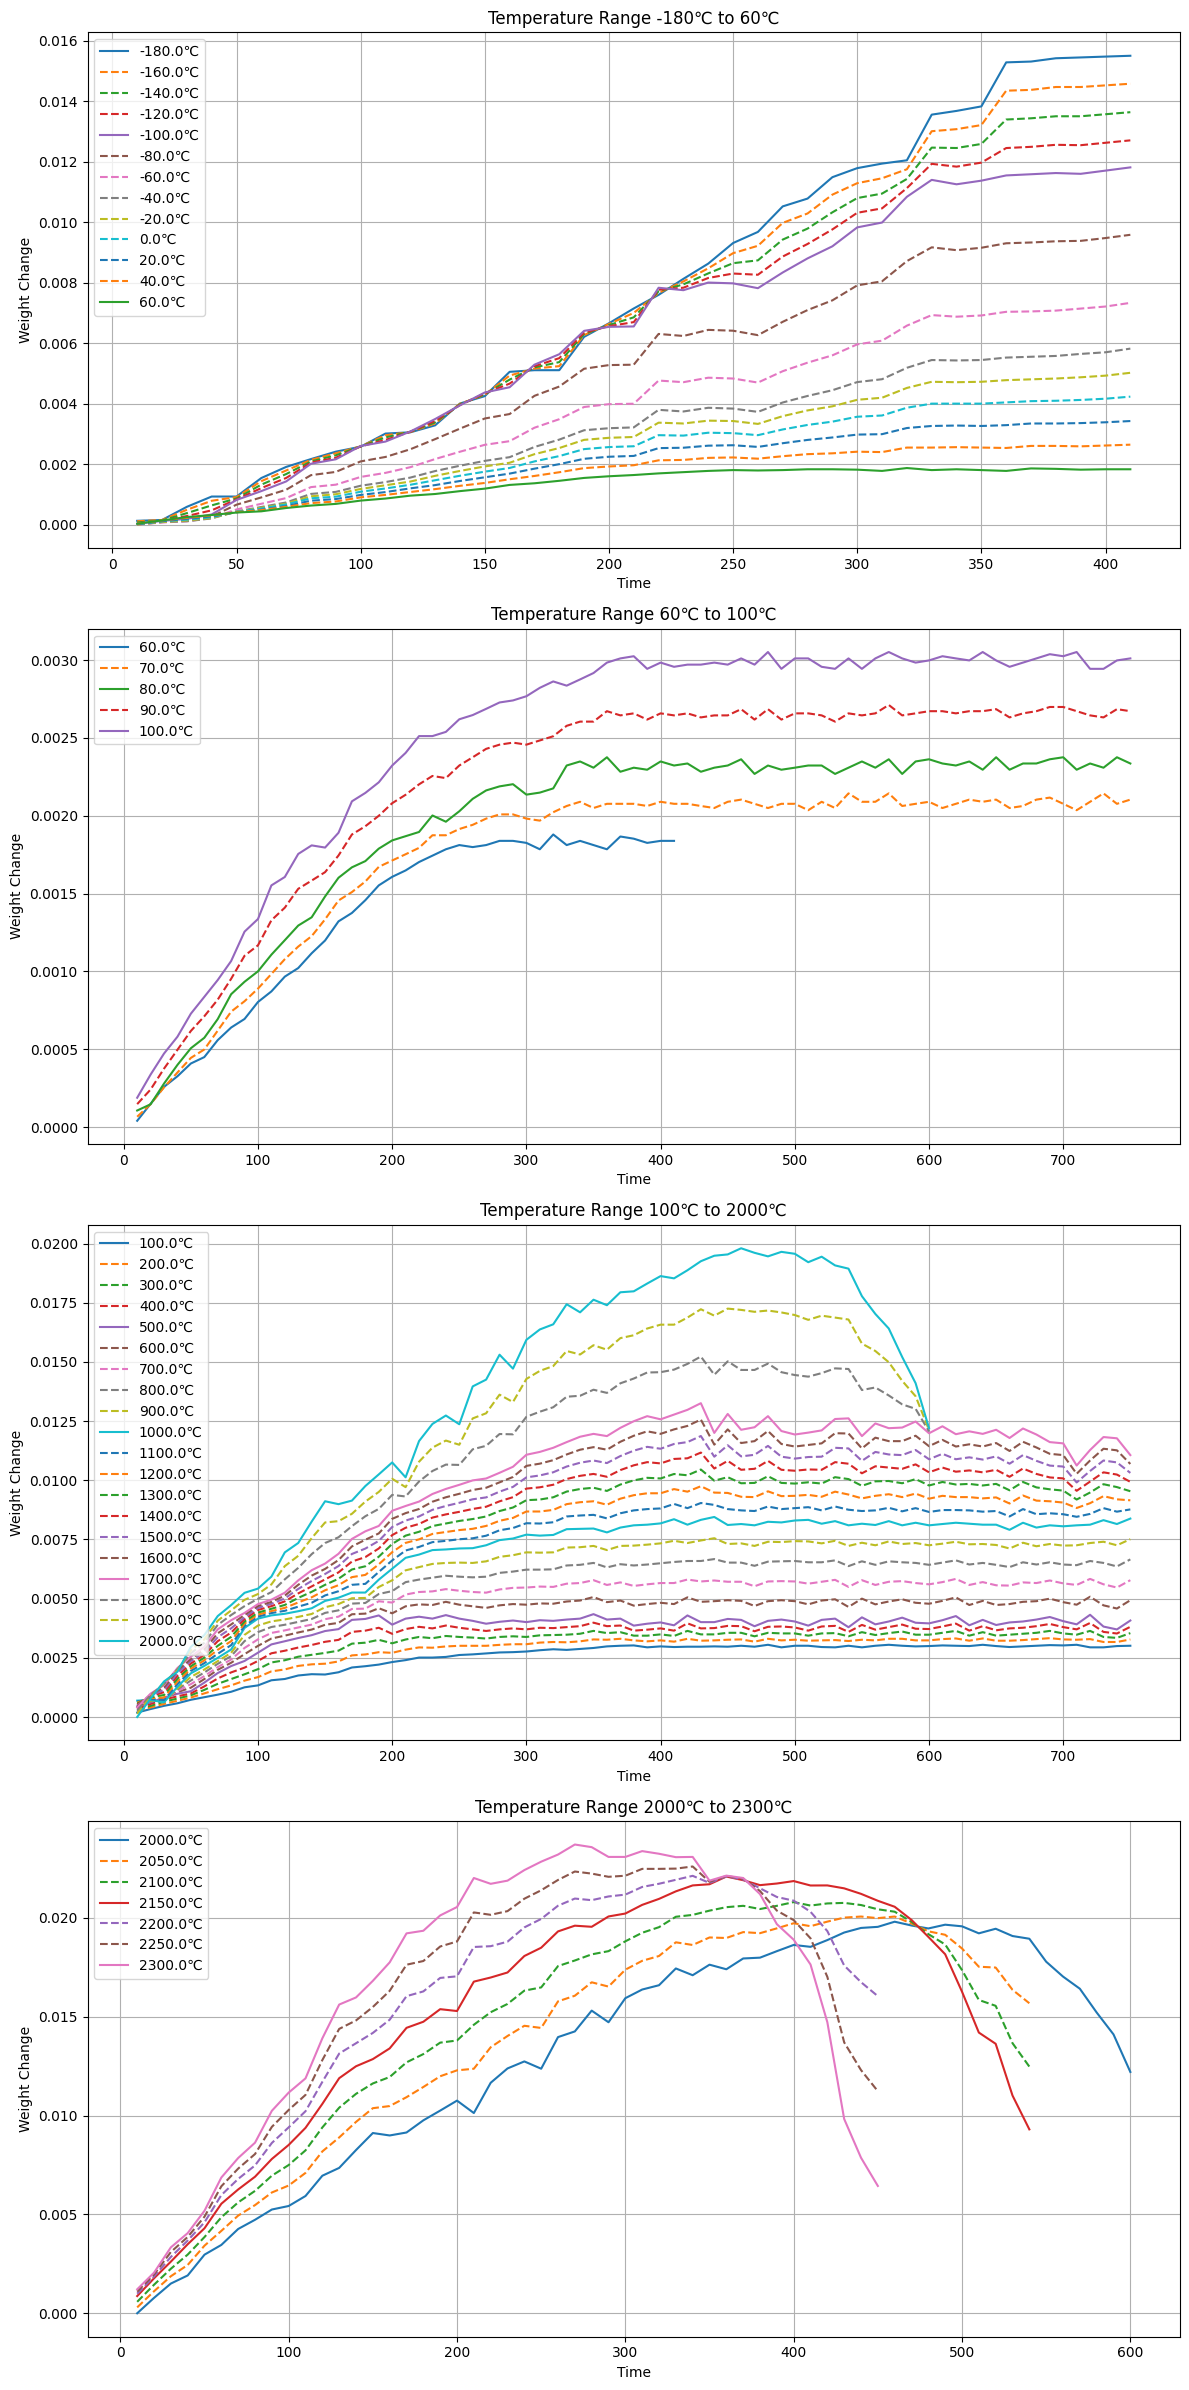

In [2]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 1. 读取初始温度数据
wb = load_workbook("x1.xlsx", data_only=True)
initial_temps = set()
for cell in wb["Sheet1"][1]:  # 读取第一行
    try:
        initial_temps.add(float(cell.value))
    except:
        continue

# 2. 处理Sheet4数据
ws = wb["Sheet4"]
data_groups = []

# 遍历所有列（两列为一组）
for col in range(1, ws.max_column, 2):
    # 检查温度一致性
    try:
        temp1 = float(ws.cell(1, col).value)
        temp2 = float(ws.cell(1, col+1).value)
        if temp1 != temp2:
            continue
    except:
        continue
    
    # 提取数据
    time_data = []
    weight_data = []
    for row in range(4, ws.max_row+1):
        time_val = ws.cell(row, col).value
        weight_val = ws.cell(row, col+1).value
        
        # 跳过空白行
        if time_val is None or weight_val is None:
            continue
            
        time_data.append(float(time_val))
        weight_data.append(float(weight_val))
    
    if len(time_data) > 0:
        data_groups.append({
            "temperature": temp1,
            "time": time_data,
            "weight": weight_data
        })

# 3. 定义温度区间配置
temp_configs = [
    {"range": (-180, 60), "step": 20, "axis": 0},
    {"range": (60, 100), "step": 10, "axis": 1},
    {"range": (100, 2000), "step": 100, "axis": 2},
    {"range": (2000, 2300), "step": 50, "axis": 3}
]

# 4. 创建绘图画布
fig, axs = plt.subplots(4, 1, figsize=(12, 24))

# 5. 处理每个温度区间
for config in temp_configs:
    start, end = config["range"]
    step = config["step"]
    ax = axs[config["axis"]]
    
    # 生成目标温度序列
    target_temps = list(range(start, end+step, step))
    
    # 筛选符合条件的数据组
    filtered_groups = [
        g for g in data_groups
        if start <= g["temperature"] <= end
        and g["temperature"] in target_temps
    ]
    
    # 绘制曲线
    for group in filtered_groups:
        temp = group["temperature"]
        line_style = "-" if temp in initial_temps else "--"
        
        ax.plot(
            group["time"],
            group["weight"],
            linestyle=line_style,
            label=f"{temp}℃"
        )
    
    # 设置图表属性
    ax.set_title(f"Temperature Range {start}℃ to {end}℃")
    ax.set_xlabel("Time")
    ax.set_ylabel("Weight Change")
    ax.legend()
    ax.grid(True)

# 6. 保存并显示结果
plt.tight_layout()
plt.savefig("thermal_analysis.png")
plt.show()

# 7. 关闭工作簿
wb.close()

In [3]:
import numpy as np
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

# ==== 初始化部分 ====
wb = load_workbook("x1.xlsx", data_only=True)

# ==== 准备Sheet5 ====
if "Sheet5" in wb.sheetnames:
    del wb["Sheet5"]
ws_result = wb.create_sheet("Sheet5")

# 创建表头
headers = ["热重温度", "最大氧化质量分数（%）", "寿命", 
          "氧化过程一次项", "氧化过程常数项"]
for col, header in enumerate(headers, 1):
    ws_result.cell(1, col, header)

# ==== 处理Sheet4数据 ====
result_data = []
ws = wb["Sheet4"]

# 遍历所有数据组
for col in range(1, ws.max_column, 2):
    # 验证温度列
    try:
        temp = float(ws.cell(1, col).value)
        if temp != float(ws.cell(1, col+1).value):
            continue
    except:
        continue

    # 收集有效数据
    time_vals = []
    weight_vals = []
    blank_count = 0
    
    for row in range(4, ws.max_row+1):
        t = ws.cell(row, col).value
        w = ws.cell(row, col+1).value
        
        if t is None or w is None:
            blank_count +=1
            if blank_count >=3: break
            continue
        else:
            blank_count = 0
            time_vals.append(float(t))
            weight_vals.append(float(w))
    
    if len(time_vals) <5: continue

    # ==== 根据温度区间处理 ====
    temp = temp
    process_type = None
    
    if -180 <= temp <=60:
        # -180~60℃处理逻辑
        A = np.mean(weight_vals[-5:]) - 0.0004
        
    elif 60 < temp <=1000:
        # 60~1000℃处理逻辑
        A = np.mean(weight_vals[-10:]) - 0.0001
        
    elif 1000 < temp <=1700:
        # 1000~1700℃处理逻辑
        sorted_weights = sorted(weight_vals)
        A = sorted_weights[-10] if len(sorted_weights)>=10 else sorted_weights[-1]
        
    elif 1700 < temp <=2300:
        # 1700~2300℃特殊处理
        B = max(weight_vals)
        C = time_vals[weight_vals.index(B)]
        x = np.array(time_vals[:weight_vals.index(B)+1])
        y = np.array(weight_vals[:weight_vals.index(B)+1])
        try:
            a, b = np.polyfit(x, y, 1)
        except:
            a, b = np.nan, np.nan
        result_data.append([temp, B*100, C, a, b])
        continue
    
    # ==== 通用处理逻辑 ====
    B = C = None
    for idx, w in enumerate(weight_vals):
        if w > A:
            B = w
            C = time_vals[idx]
            break
    
    if B is None: continue

    # 线性拟合
    x = np.array(time_vals[:idx+1])
    y = np.array(weight_vals[:idx+1])
    try:
        a, b = np.polyfit(x, y, 1)
    except:
        a, b = np.nan, np.nan
    
    result_data.append([temp, B*100, C, a, b])

# ==== 写入结果 ====
# 按温度排序后写入
sorted_results = sorted(result_data, key=lambda x: x[0])
for row_idx, (temp, B, C, a, b) in enumerate(sorted_results, 2):
    ws_result.cell(row_idx, 1, temp)
    ws_result.cell(row_idx, 2, B)
    ws_result.cell(row_idx, 3, C)
    ws_result.cell(row_idx, 4, a)
    ws_result.cell(row_idx, 5, b)

# ==== 保存文件 ====
try:
    wb.save("x1.xlsx")
    print("处理成功！共处理{}组数据".format(len(result_data)))
except PermissionError:
    print("错误：文件被占用，请关闭Excel后重试")
except Exception as e:
    print("保存失败：", str(e))
finally:
    wb.close()

处理成功！共处理249组数据


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/tmp/ipykernel_583/1940400973.py:86: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_583/1940400973.py:86: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
 

<Figure size 3600x2400 with 0 Axes>

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

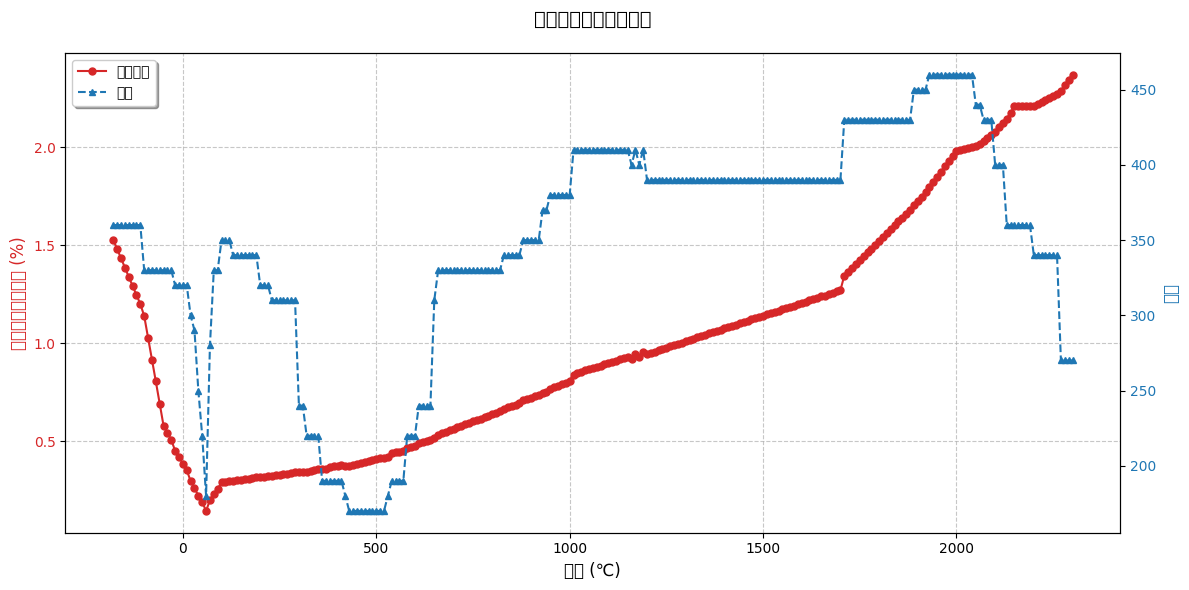

In [ ]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 加载工作簿
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet5"]

# 数据收集
temperatures = []
mass_fractions = []
lifetimes = []

# 从第二行开始读取数据
for row in ws.iter_rows(min_row=2):
    # 读取温度值
    try:
        temp = float(row[0].value)
        mass = float(row[1].value)
        life = float(row[2].value)
    except (TypeError, ValueError):
        continue
    
    temperatures.append(temp)
    mass_fractions.append(mass)
    lifetimes.append(life)

# 按温度排序数据
sorted_data = sorted(zip(temperatures, mass_fractions, lifetimes), key=lambda x: x[0])
temperatures = [x[0] for x in sorted_data]
mass_fractions = [x[1] for x in sorted_data]
lifetimes = [x[2] for x in sorted_data]

# 创建画布
plt.figure(figsize=(12, 8), dpi=300)


# 绘制双纵坐标图
fig, ax1 = plt.subplots(figsize=(12, 6))

# 第一个y轴（质量分数）
color = 'tab:red'
ax1.set_xlabel('温度 (℃)', fontsize=12, fontfamily='SimHei')
ax1.set_ylabel('最大氧化质量分数 (%)', color=color, fontsize=12)
ax1.plot(temperatures, mass_fractions, 
        color=color, 
        linestyle='-', 
        marker='o',
        markersize=5,
        linewidth=1.5,
        label='质量分数')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# 第二个y轴（寿命）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('寿命', color=color, fontsize=12)
ax2.plot(temperatures, lifetimes, 
        color=color, 
        linestyle='--', 
        marker='^',
        markersize=5,
        linewidth=1.5,
        label='寿命')
ax2.tick_params(axis='y', labelcolor=color)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
         loc='upper left',
         fontsize=10,
         frameon=True,
         shadow=True)

# 设置标题和网格
plt.title("氧化特性温度依赖关系", 
         fontsize=14, 
         pad=20,
         fontfamily='SimHei',
         fontweight='bold')

# 优化布局
fig.tight_layout()

# 保存图像
plt.savefig('氧化特性分析.png', 
          bbox_inches='tight', 
          dpi=300,
          facecolor='white')

# 显示图像
plt.show()

# 关闭工作簿
wb.close()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

<Figure size 3600x2400 with 0 Axes>

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

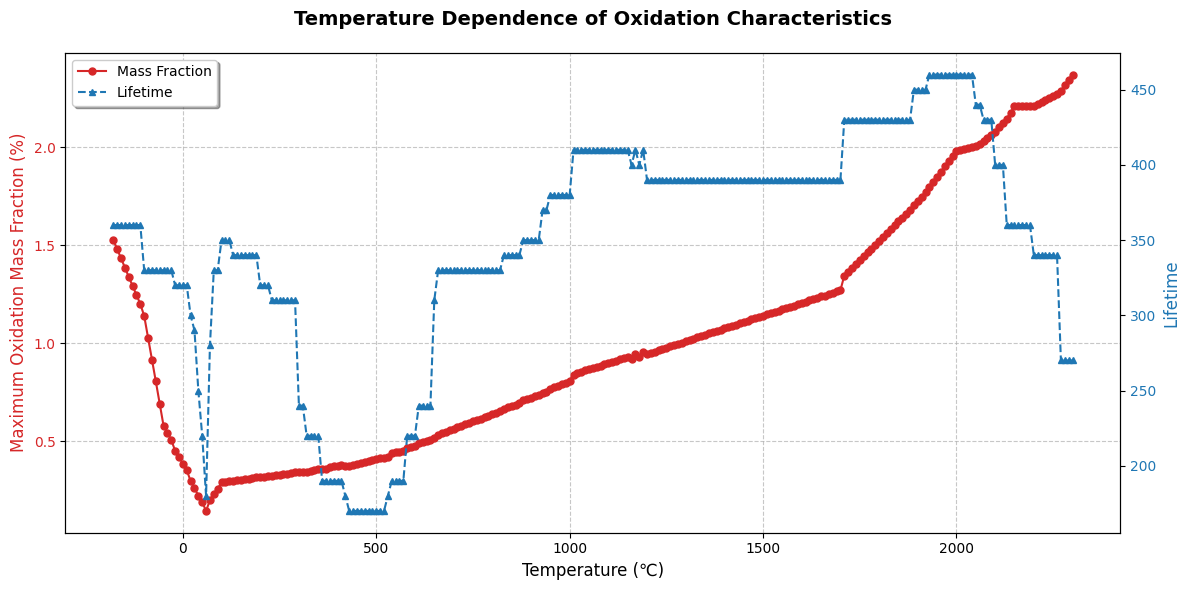

In [8]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 加载工作簿
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet5"]

# 数据收集
temperatures = []
mass_fractions = []
lifetimes = []

# 从第二行开始读取数据
for row in ws.iter_rows(min_row=2):
    # 读取温度值
    try:
        temp = float(row[0].value)
        mass = float(row[1].value)
        life = float(row[2].value)
    except (TypeError, ValueError):
        continue

    temperatures.append(temp)
    mass_fractions.append(mass)
    lifetimes.append(life)

# 按温度排序数据
sorted_data = sorted(zip(temperatures, mass_fractions, lifetimes), key=lambda x: x[0])
temperatures = [x[0] for x in sorted_data]
mass_fractions = [x[1] for x in sorted_data]
lifetimes = [x[2] for x in sorted_data]

# 创建画布
plt.figure(figsize=(12, 8), dpi=300)

# 绘制双纵坐标图
fig, ax1 = plt.subplots(figsize=(12, 6))

# 第一个y轴（质量分数）
color = 'tab:red'
ax1.set_xlabel('Temperature (℃)', fontsize=12)
ax1.set_ylabel('Maximum Oxidation Mass Fraction (%)', color=color, fontsize=12)
ax1.plot(temperatures, mass_fractions,
         color=color,
         linestyle='-',
         marker='o',
         markersize=5,
         linewidth=1.5,
         label='Mass Fraction')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# 第二个y轴（寿命）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Lifetime', color=color, fontsize=12)
ax2.plot(temperatures, lifetimes,
         color=color,
         linestyle='--',
         marker='^',
         markersize=5,
         linewidth=1.5,
         label='Lifetime')
ax2.tick_params(axis='y', labelcolor=color)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left',
           fontsize=10,
           frameon=True,
           shadow=True)

# 设置标题和网格
plt.title("Temperature Dependence of Oxidation Characteristics",
          fontsize=14,
          pad=20,
          fontweight='bold')

# 优化布局
fig.tight_layout()

# 保存图像
plt.savefig('OxidationCharacteristicsAnalysis.png',
            bbox_inches='tight',
            dpi=300,
            facecolor='white')

# 显示图像
plt.show()

# 关闭工作簿
wb.close()
    

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

<Figure size 3600x2400 with 0 Axes>

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

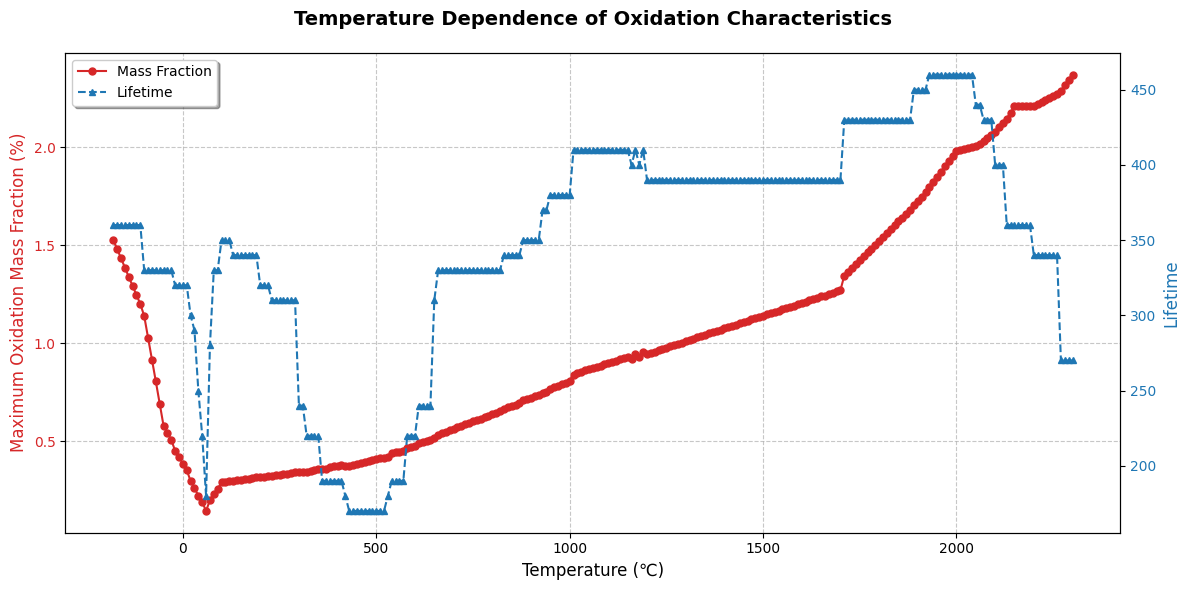

恒温温度[456.7]℃下预测的寿命为: 311.1836630392538


In [11]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from sklearn.linear_model import LinearRegression
import numpy as np

# 加载工作簿
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet5"]

# 数据收集
temperatures = []
mass_fractions = []
lifetimes = []

# 从第二行开始读取数据
for row in ws.iter_rows(min_row=2):
    # 读取温度值
    try:
        temp = float(row[0].value)
        mass = float(row[1].value)
        life = float(row[2].value)
    except (TypeError, ValueError):
        continue

    temperatures.append(temp)
    mass_fractions.append(mass)
    lifetimes.append(life)

# 按温度排序数据
sorted_data = sorted(zip(temperatures, mass_fractions, lifetimes), key=lambda x: x[0])
temperatures = [x[0] for x in sorted_data]
mass_fractions = [x[1] for x in sorted_data]
lifetimes = [x[2] for x in sorted_data]

# 创建画布
plt.figure(figsize=(12, 8), dpi=300)

# 绘制双纵坐标图
fig, ax1 = plt.subplots(figsize=(12, 6))

# 第一个y轴（质量分数）
color = 'tab:red'
ax1.set_xlabel('Temperature (℃)', fontsize=12)
ax1.set_ylabel('Maximum Oxidation Mass Fraction (%)', color=color, fontsize=12)
ax1.plot(temperatures, mass_fractions,
         color=color,
         linestyle='-',
         marker='o',
         markersize=5,
         linewidth=1.5,
         label='Mass Fraction')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# 第二个y轴（寿命）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Lifetime', color=color, fontsize=12)
ax2.plot(temperatures, lifetimes,
         color=color,
         linestyle='--',
         marker='^',
         markersize=5,
         linewidth=1.5,
         label='Lifetime')
ax2.tick_params(axis='y', labelcolor=color)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left',
           fontsize=10,
           frameon=True,
           shadow=True)

# 设置标题和网格
plt.title("Temperature Dependence of Oxidation Characteristics",
          fontsize=14,
          pad=20,
          fontweight='bold')

# 优化布局
fig.tight_layout()

# 保存图像
plt.savefig('OxidationCharacteristicsAnalysis.png',
            bbox_inches='tight',
            dpi=300,
            facecolor='white')

# 显示图像
plt.show()

# 关闭工作簿
wb.close()

# 线性回归模型训练
X = np.array(temperatures).reshape(-1, 1)
y = np.array(lifetimes)
model = LinearRegression()
model.fit(X, y)

# 输入温度 X 进行预测
try:
    input_temperature = float(input("请输入要预测的恒温温度 (℃): "))
    predicted_lifetime = model.predict([[input_temperature]])
    print(f"恒温温度{[input_temperature]}℃下预测的寿命为: {predicted_lifetime[0]}")
except ValueError:
    print("输入的温度不是有效的数字，请输入一个有效的浮点数。")
    

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun


=== Segmented Regression Results ===

Range: -180℃-60℃
Data Points: 24
Best Polynomial Degree: 3
Regression Equation: y = 3.1080e+02 + -8.9290e-01x^1 + -9.0840e-03x^2 + -3.3557e-05x^3
R² Value: 0.8966

Range: 60℃-300℃
Data Points: 24
Best Polynomial Degree: 3
Regression Equation: y = -1.1958e+02 + 8.3477e+00x^1 + -4.6352e-02x^2 + 7.8777e-05x^3
R² Value: 0.7623

Range: 300℃-700℃
Data Points: 40
Best Polynomial Degree: 3
Regression Equation: y = 4.3899e+02 + -2.5229e-01x^1 + -2.5373e-03x^2 + 3.9387e-06x^3
R² Value: 0.9515

Range: 700℃-2000℃
Data Points: 130
Best Polynomial Degree: 3
Regression Equation: y = -4.8201e+02 + 1.9767e+00x^1 + -1.4725e-03x^2 + 3.6257e-07x^3
R² Value: 0.8804

Range: 2000℃-2300℃
Data Points: 30
Best Polynomial Degree: 3
Regression Equation: y = 5.6714e+04 + -7.7798e+01x^1 + 3.6070e-02x^2 + -5.6148e-06x^3
R² Value: 0.9305

=== Prediction for 500℃ ===
Cubic Spline Interpolation: 170.00


ValueError: invalid literal for int() with base 10: '60℃'

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

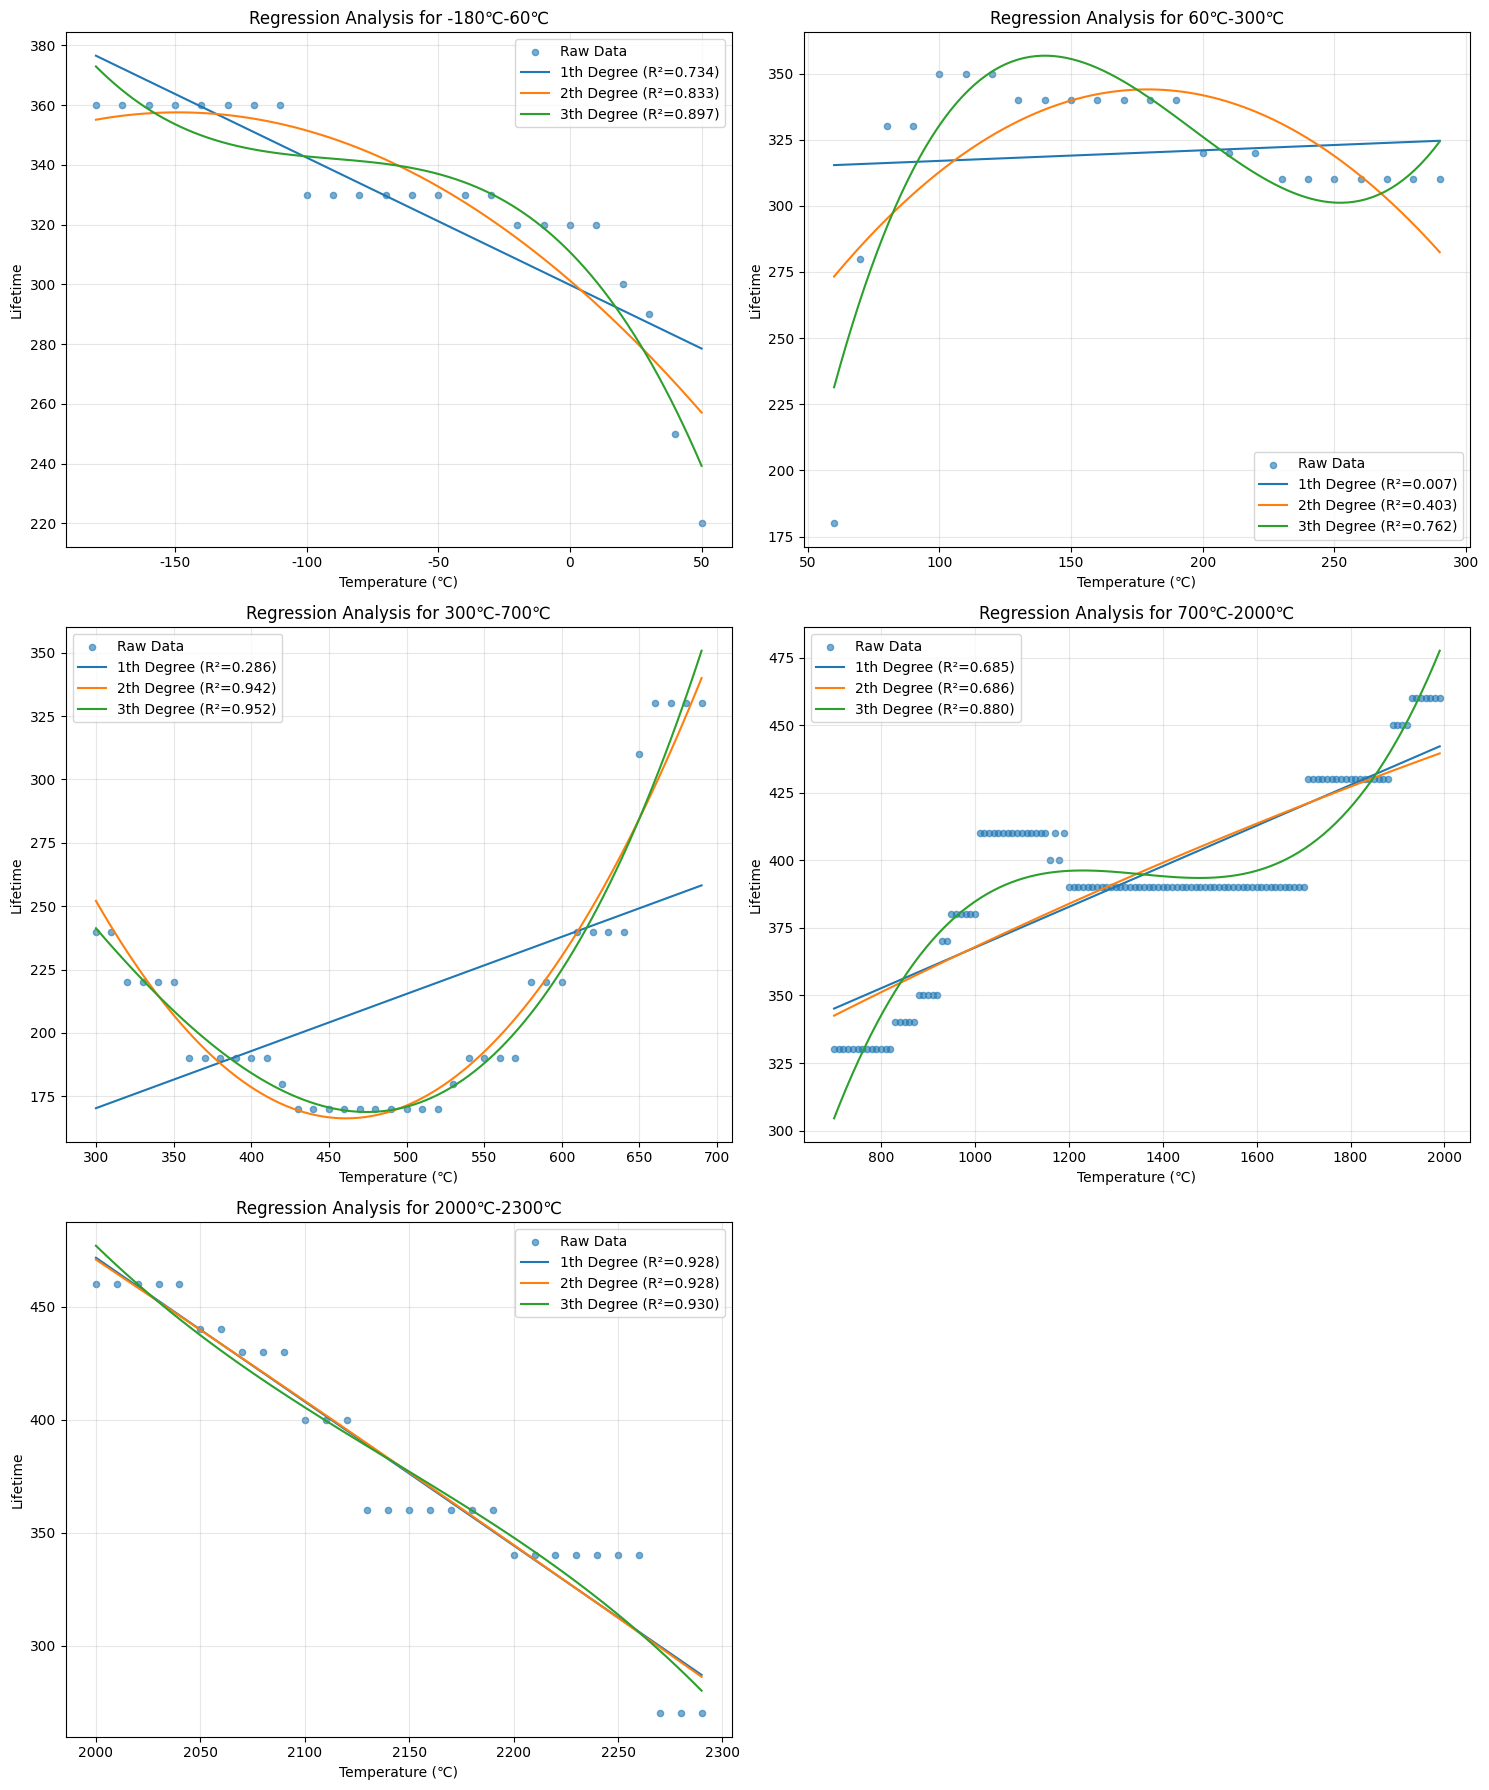

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from sklearn.metrics import r2_score
from openpyxl import load_workbook

# 配置中文字体（保留中文支持，标签改为英文后仍需防止负号乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ------------------ 数据准备阶段 ------------------
# 加载数据
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet5"]

# 创建DataFrame（列名改为英文）
data = []
for row in ws.iter_rows(min_row=2):
    try:
        data.append([float(cell.value) for cell in row[:3]])
    except:
        continue

df = pd.DataFrame(data, columns=["Temperature", "Mass Fraction", "Lifetime"])
df = df.sort_values("Temperature").reset_index(drop=True)

# ------------------ 分段回归分析 ------------------
# 定义温度区间（可调整）
segments = [
    (-180, 60),
    (60, 300),
    (300, 700),
    (700, 2000),
    (2000, 2300)
]

# 存储回归结果
results = []
plt.figure(figsize=(15, 18))

# 遍历每个温度区间
for idx, (start, end) in enumerate(segments, 1):
    # 提取区间数据
    mask = (df["Temperature"] >= start) & (df["Temperature"] < end)
    segment_df = df[mask].copy()
    
    if len(segment_df) < 10:  # 数据量不足跳过
        continue
    
    # 准备回归数据
    X = segment_df["Temperature"].values
    y = segment_df["Lifetime"].values
    
    # 创建子图
    ax = plt.subplot(3, 2, idx)
    ax.scatter(X, y, s=20, alpha=0.6, label='Raw Data')
    
    # 尝试不同阶次回归
    best_r2 = -np.inf
    best_model = None
    
    for degree in [1, 2, 3]:
        try:
            coeffs = np.polyfit(X, y, degree)
            model = np.poly1d(coeffs)
            y_pred = model(X)
            current_r2 = r2_score(y, y_pred)
            
            # 可视化拟合曲线
            x_plot = np.linspace(X.min(), X.max(), 100)
            ax.plot(x_plot, model(x_plot), 
                   label=f'{degree}th Degree (R²={current_r2:.3f})')
            
            # 记录最佳模型
            if current_r2 > best_r2:
                best_r2 = current_r2
                best_model = {
                    'degree': degree,
                    'coeffs': coeffs,
                    'r2': current_r2
                }
                
        except Exception as e:
            print(f"Fitting failed for {start}-{end}℃ at {degree} degrees: {str(e)}")
    
    # 记录结果
    results.append({
        'Range': f"{start}℃-{end}℃",
        'Data Points': len(X),
        'Best Degree': best_model['degree'],
        'Coefficients': best_model['coeffs'],
        'R²': best_model['r2']
    })
    
    # 图表装饰（标签改为英文）
    ax.set_title(f'Regression Analysis for {start}℃-{end}℃')
    ax.set_xlabel('Temperature (℃)')
    ax.set_ylabel('Lifetime')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Segmented_Regression_Analysis.png', dpi=300)

# ------------------ 预测与插值 ------------------
def format_equation(coeffs):
    """将系数转换为方程字符串（保留原有逻辑）"""
    terms = []
    for power, coeff in enumerate(coeffs[::-1]):
        if power == 0:
            term = f"{coeff:.4e}"
        else:
            term = f"{coeff:.4e}x^{power}"
        terms.append(term)
    return "y = " + " + ".join(terms)

# 输出回归结果（英文提示）
print("\n=== Segmented Regression Results ===")
result_df = pd.DataFrame(results)
for _, row in result_df.iterrows():
    print(f"\nRange: {row['Range']}")
    print(f"Data Points: {row['Data Points']}")
    print(f"Best Polynomial Degree: {row['Best Degree']}")
    print(f"Regression Equation: {format_equation(row['Coefficients'])}")
    print(f"R² Value: {row['R²']:.4f}")

# 示例预测温度
predict_temp = 500
print(f"\n=== Prediction for {predict_temp}℃ ===")

# 方法1：插值法（三次样条）
try:
    spline = interpolate.interp1d(df["Temperature"], df["Lifetime"], kind='cubic')
    interp_value = spline(predict_temp)
    print(f"Cubic Spline Interpolation: {interp_value:.2f}")
except:
    interp_value = np.nan

# 方法2：回归预测
for seg in results:
    start, end = map(int, seg['Range'].split('℃-'))
    if start <= predict_temp < end:
        model = np.poly1d(seg['Coefficients'])
        regress_value = model(predict_temp)
        print(f"Regression Prediction ({seg['Range']}): {regress_value:.2f}")
        break

# ------------------ 综合可视化 ------------------
plt.figure(figsize=(12, 6))
plt.scatter(df["Temperature"], df["Lifetime"], s=15, alpha=0.6, label='Raw Data')

# 绘制全区间回归曲线
for seg in results:
    coeffs = seg['Coefficients']
    model = np.poly1d(coeffs)
    start, end = map(int, seg['Range'].split('℃-'))
    x_range = np.linspace(start, end, 100)
    plt.plot(x_range, model(x_range), 
            linewidth=2,
            label=f'{seg["Range"]}\n{format_equation(coeffs)}')

plt.title("Regression Analysis of Lifetime Across Temperature Ranges")
plt.xlabel("Temperature (℃)")
plt.ylabel("Lifetime")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 图例位置保持不变
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Comprehensive_Regression_Analysis.png', dpi=300, bbox_inches='tight')

# ------------------ 结果保存 ------------------
# 保存回归结果到Excel（Sheet名保持中文，因需求仅改图表标签）
with pd.ExcelWriter('x1_analysis.xlsx') as writer:
    result_df.to_excel(writer, sheet_name='回归分析', index=False)
    df.to_excel(writer, sheet_name='原始数据', index=False)

print("\nProcessing complete! Results saved to:")
print("- Segmented_Regression_Analysis.png")
print("- Comprehensive_Regression_Analysis.png")
print("- x1_analysis.xlsx")

# 关闭工作簿
wb.close()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_950/4164658301.py:109: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_950/4164658301.py:109: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing fro


=== 分段回归结果 ===

区间：-180℃-60℃
数据点：24个
最佳多项式次数：3
回归方程：y = 3.1080e+02 + -8.9290e-01x^1 + -9.0840e-03x^2 + -3.3557e-05x^3
R²值：0.8966

区间：60℃-300℃
数据点：24个
最佳多项式次数：5
回归方程：y = -1.4045e+03 + 5.3054e+01x^1 + -6.1484e-01x^2 + 3.4293e-03x^3 + -9.2764e-06x^4 + 9.7590e-09x^5
R²值：0.9425

区间：300℃-700℃
数据点：40个
最佳多项式次数：3
回归方程：y = 4.3899e+02 + -2.5229e-01x^1 + -2.5373e-03x^2 + 3.9387e-06x^3
R²值：0.9515

区间：700℃-2000℃
数据点：130个
最佳多项式次数：3
回归方程：y = -4.8201e+02 + 1.9767e+00x^1 + -1.4725e-03x^2 + 3.6257e-07x^3
R²值：0.8804

区间：2000℃-2300℃
数据点：30个
最佳多项式次数：3
回归方程：y = 5.6714e+04 + -7.7798e+01x^1 + 3.6070e-02x^2 + -5.6148e-06x^3
R²值：0.9305

=== 温度500℃预测 ===
插值法预测寿命：170.00


ValueError: invalid literal for int() with base 10: '60℃'

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

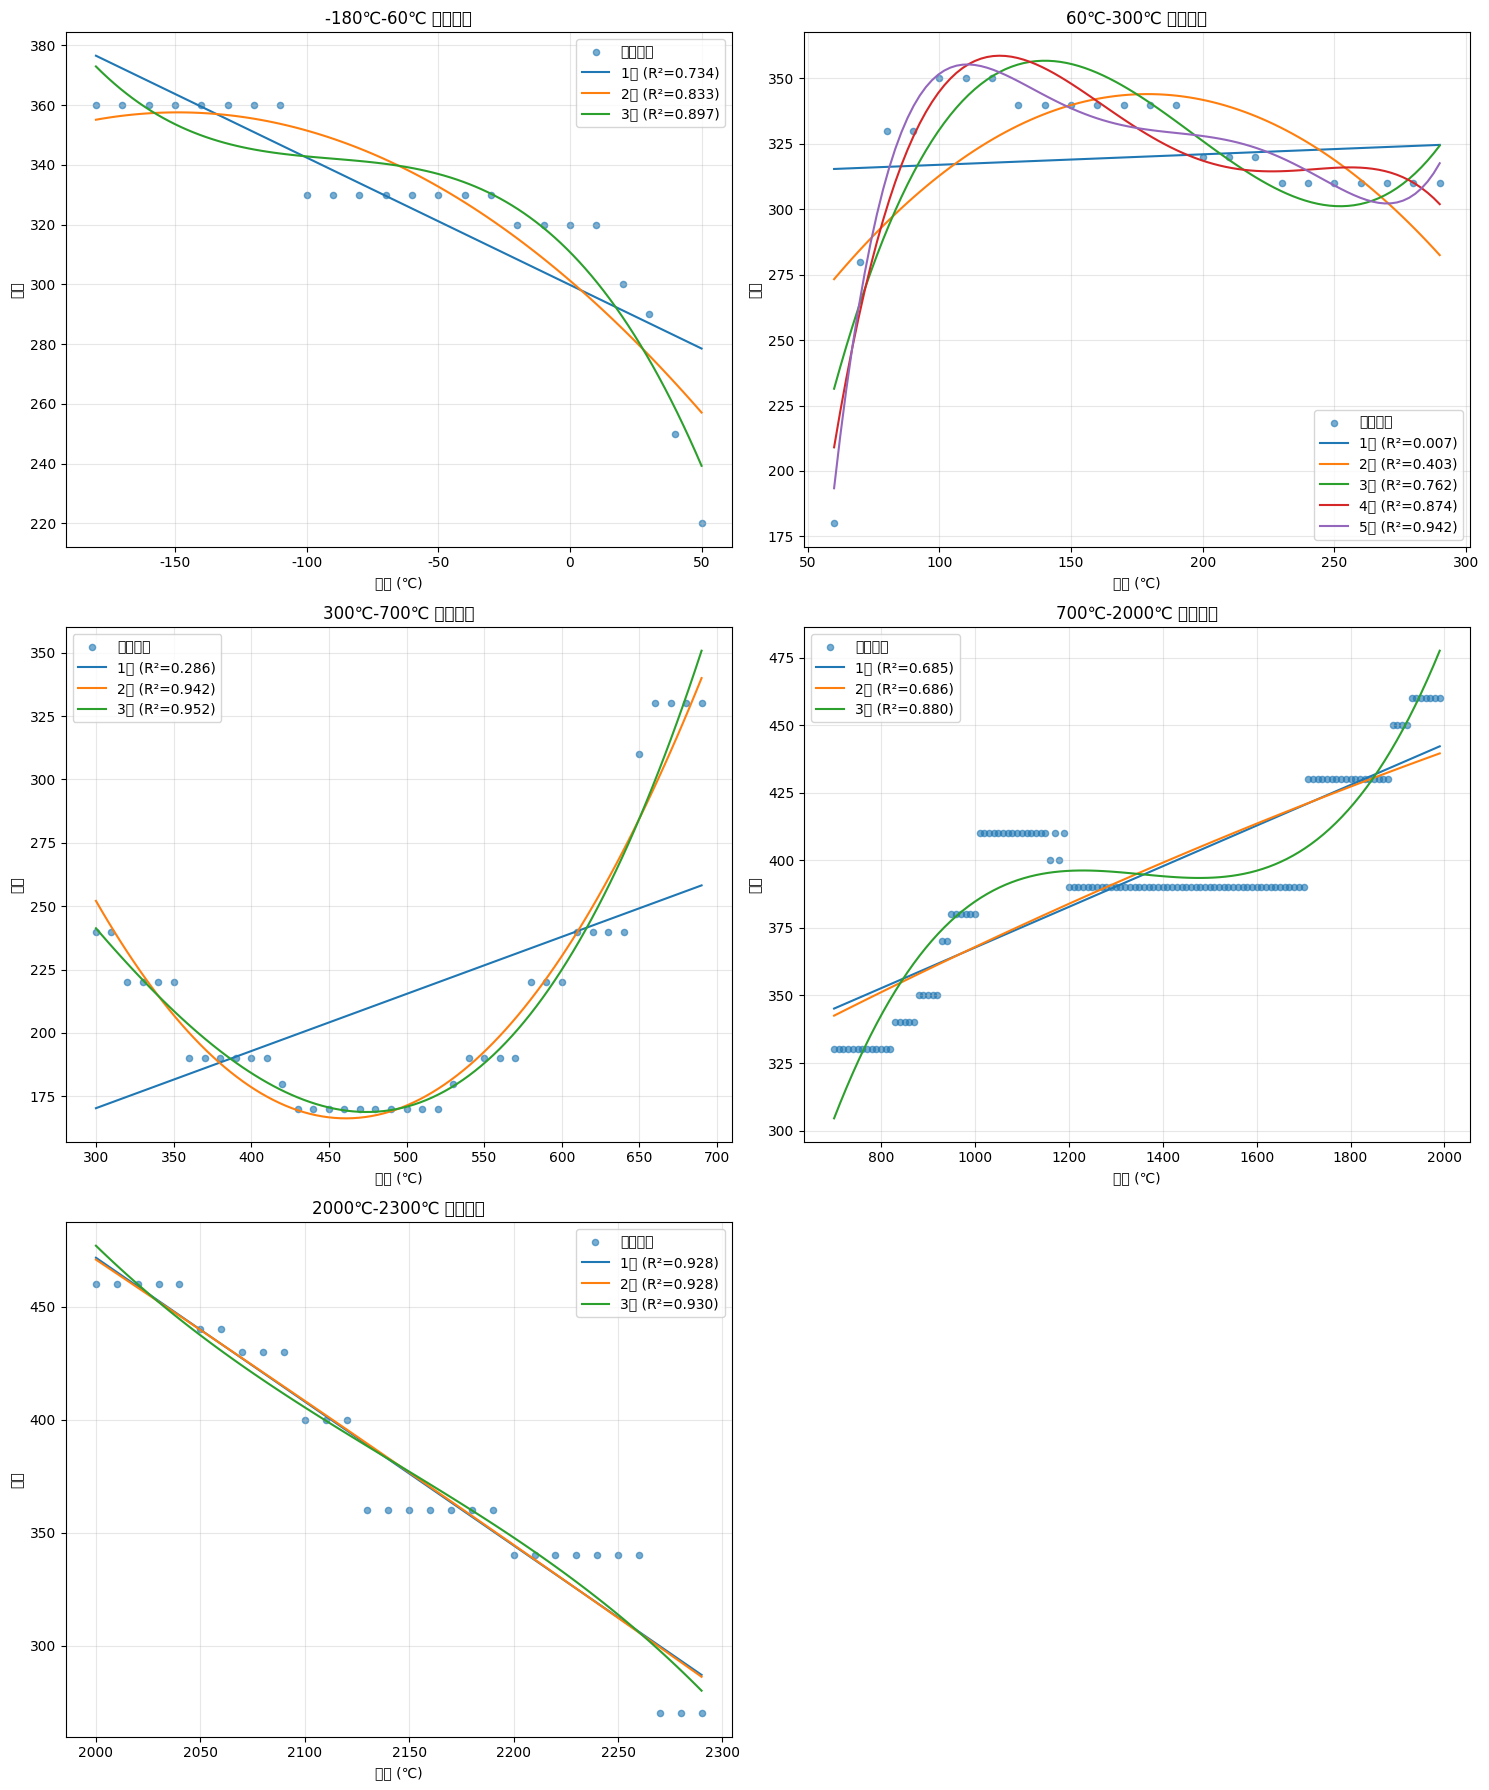

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from sklearn.metrics import r2_score
from openpyxl import load_workbook

# 配置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ------------------ 数据准备阶段 ------------------
# 加载数据
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet5"]

# 创建DataFrame
data = []
for row in ws.iter_rows(min_row=2):
    try:
        data.append([float(cell.value) for cell in row[:3]])
    except:
        continue

df = pd.DataFrame(data, columns=["温度", "质量分数", "寿命"])
df = df.sort_values("温度").reset_index(drop=True)

# ------------------ 分段回归分析 ------------------
# 定义温度区间（可调整）
segments = [
    (-180, 60),
    (60, 300),
    (300, 700),
    (700, 2000),
    (2000, 2300)
]

# 存储回归结果
results = []
plt.figure(figsize=(15, 18))

# 遍历每个温度区间
for idx, (start, end) in enumerate(segments, 1):
    # 提取区间数据
    mask = (df["温度"] >= start) & (df["温度"] < end)
    segment_df = df[mask].copy()
    
    if len(segment_df) < 10:  # 数据量不足跳过
        continue
    
    # 准备回归数据
    X = segment_df["温度"].values
    y = segment_df["寿命"].values
    
    # 创建子图
    ax = plt.subplot(3, 2, idx)
    ax.scatter(X, y, s=20, alpha=0.6, label='原始数据')
    
    # 尝试不同阶次回归
    best_r2 = -np.inf
    best_model = None
    
    # 对于60-300区间，增加4次和5次多项式
    if (start, end) == (60, 300):
        degrees_to_try = [1, 2, 3, 4, 5]
    else:
        degrees_to_try = [1, 2, 3]
    
    for degree in degrees_to_try:
        try:
            coeffs = np.polyfit(X, y, degree)
            model = np.poly1d(coeffs)
            y_pred = model(X)
            current_r2 = r2_score(y, y_pred)
            
            # 可视化拟合曲线
            x_plot = np.linspace(X.min(), X.max(), 100)
            ax.plot(x_plot, model(x_plot), 
                   label=f'{degree}次 (R²={current_r2:.3f})')
            
            # 记录最佳模型
            if current_r2 > best_r2:
                best_r2 = current_r2
                best_model = {
                    'degree': degree,
                    'coeffs': coeffs,
                    'r2': current_r2
                }
                
        except Exception as e:
            print(f"区间{start}-{end} {degree}次拟合失败：{str(e)}")
    
    # 记录结果
    results.append({
        '区间': f"{start}℃-{end}℃",
        '数据量': len(X),
        '最佳次数': best_model['degree'],
        '回归系数': best_model['coeffs'],
        'R²': best_model['r2']
    })
    
    # 图表装饰
    ax.set_title(f'{start}℃-{end}℃ 回归分析')
    ax.set_xlabel('温度 (℃)')
    ax.set_ylabel('寿命')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('分段回归分析.png', dpi=300)

# ------------------ 预测与插值 ------------------
def format_equation(coeffs):
    """将系数转换为方程字符串"""
    terms = []
    for power, coeff in enumerate(coeffs[::-1]):
        if power == 0:
            term = f"{coeff:.4e}"
        else:
            term = f"{coeff:.4e}x^{power}"
        terms.append(term)
    return "y = " + " + ".join(terms)

# 输出回归结果
print("\n=== 分段回归结果 ===")
result_df = pd.DataFrame(results)
for _, row in result_df.iterrows():
    print(f"\n区间：{row['区间']}")
    print(f"数据点：{row['数据量']}个")
    print(f"最佳多项式次数：{row['最佳次数']}")
    print(f"回归方程：{format_equation(row['回归系数'])}")
    print(f"R²值：{row['R²']:.4f}")

# 示例预测温度
predict_temp = 500
print(f"\n=== 温度{predict_temp}℃预测 ===")

# 方法1：插值法（三次样条）
try:
    spline = interpolate.interp1d(df["温度"], df["寿命"], kind='cubic')
    interp_value = spline(predict_temp)
    print(f"插值法预测寿命：{interp_value:.2f}")
except:
    interp_value = np.nan

# 方法2：回归预测
for seg in results:
    start, end = map(int, seg['区间'].split('℃-'))
    if start <= predict_temp < end:
        model = np.poly1d(seg['回归系数'])
        regress_value = model(predict_temp)
        print(f"回归预测寿命（{seg['区间']}）：{regress_value:.2f}")
        break

# ------------------ 综合可视化 ------------------
plt.figure(figsize=(12, 6))
plt.scatter(df["温度"], df["寿命"], s=15, alpha=0.6, label='原始数据')

# 绘制全区间回归曲线
for seg in results:
    coeffs = seg['回归系数']
    model = np.poly1d(coeffs)
    start, end = map(int, seg['区间'].split('℃-'))
    x_range = np.linspace(start, end, 100)
    plt.plot(x_range, model(x_range), 
            linewidth=2,
            label=f'{seg["区间"]}\n{format_equation(coeffs)}')

plt.title("全温度区间寿命变化回归分析")
plt.xlabel("温度 (℃)")
plt.ylabel("寿命")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('综合回归分析.png', dpi=300, bbox_inches='tight')

# ------------------ 结果保存 ------------------
# 保存回归结果到Excel
with pd.ExcelWriter('x1_analysis.xlsx') as writer:
    result_df.to_excel(writer, sheet_name='回归分析', index=False)
    df.to_excel(writer, sheet_name='原始数据', index=False)

print("\n处理完成！结果已保存到：")
print("- 分段回归分析.png")
print("- 综合回归分析.png")
print("- x1_analysis.xlsx")

# 关闭工作簿
wb.close()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun


=== Segmented Regression Results ===

Range: -180°C-60°C
Data Points: 24
Best Polynomial Degree: 3
Regression Equation: y = 3.1080e+02 + -8.9290e-01x^1 + -9.0840e-03x^2 + -3.3557e-05x^3
R² Value: 0.8966

Range: 60°C-300°C
Data Points: 24
Best Polynomial Degree: 5
Regression Equation: y = -1.4045e+03 + 5.3054e+01x^1 + -6.1484e-01x^2 + 3.4293e-03x^3 + -9.2764e-06x^4 + 9.7590e-09x^5
R² Value: 0.9425

Range: 300°C-700°C
Data Points: 40
Best Polynomial Degree: 3
Regression Equation: y = 4.3899e+02 + -2.5229e-01x^1 + -2.5373e-03x^2 + 3.9387e-06x^3
R² Value: 0.9515

Range: 700°C-2000°C
Data Points: 130
Best Polynomial Degree: 3
Regression Equation: y = -4.8201e+02 + 1.9767e+00x^1 + -1.4725e-03x^2 + 3.6257e-07x^3
R² Value: 0.8804

Range: 2000°C-2300°C
Data Points: 30
Best Polynomial Degree: 3
Regression Equation: y = 5.6714e+04 + -7.7798e+01x^1 + 3.6070e-02x^2 + -5.6148e-06x^3
R² Value: 0.9305

=== Prediction at 500°C ===
Interpolation Prediction: 170.00


ValueError: invalid literal for int() with base 10: '60°C'

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

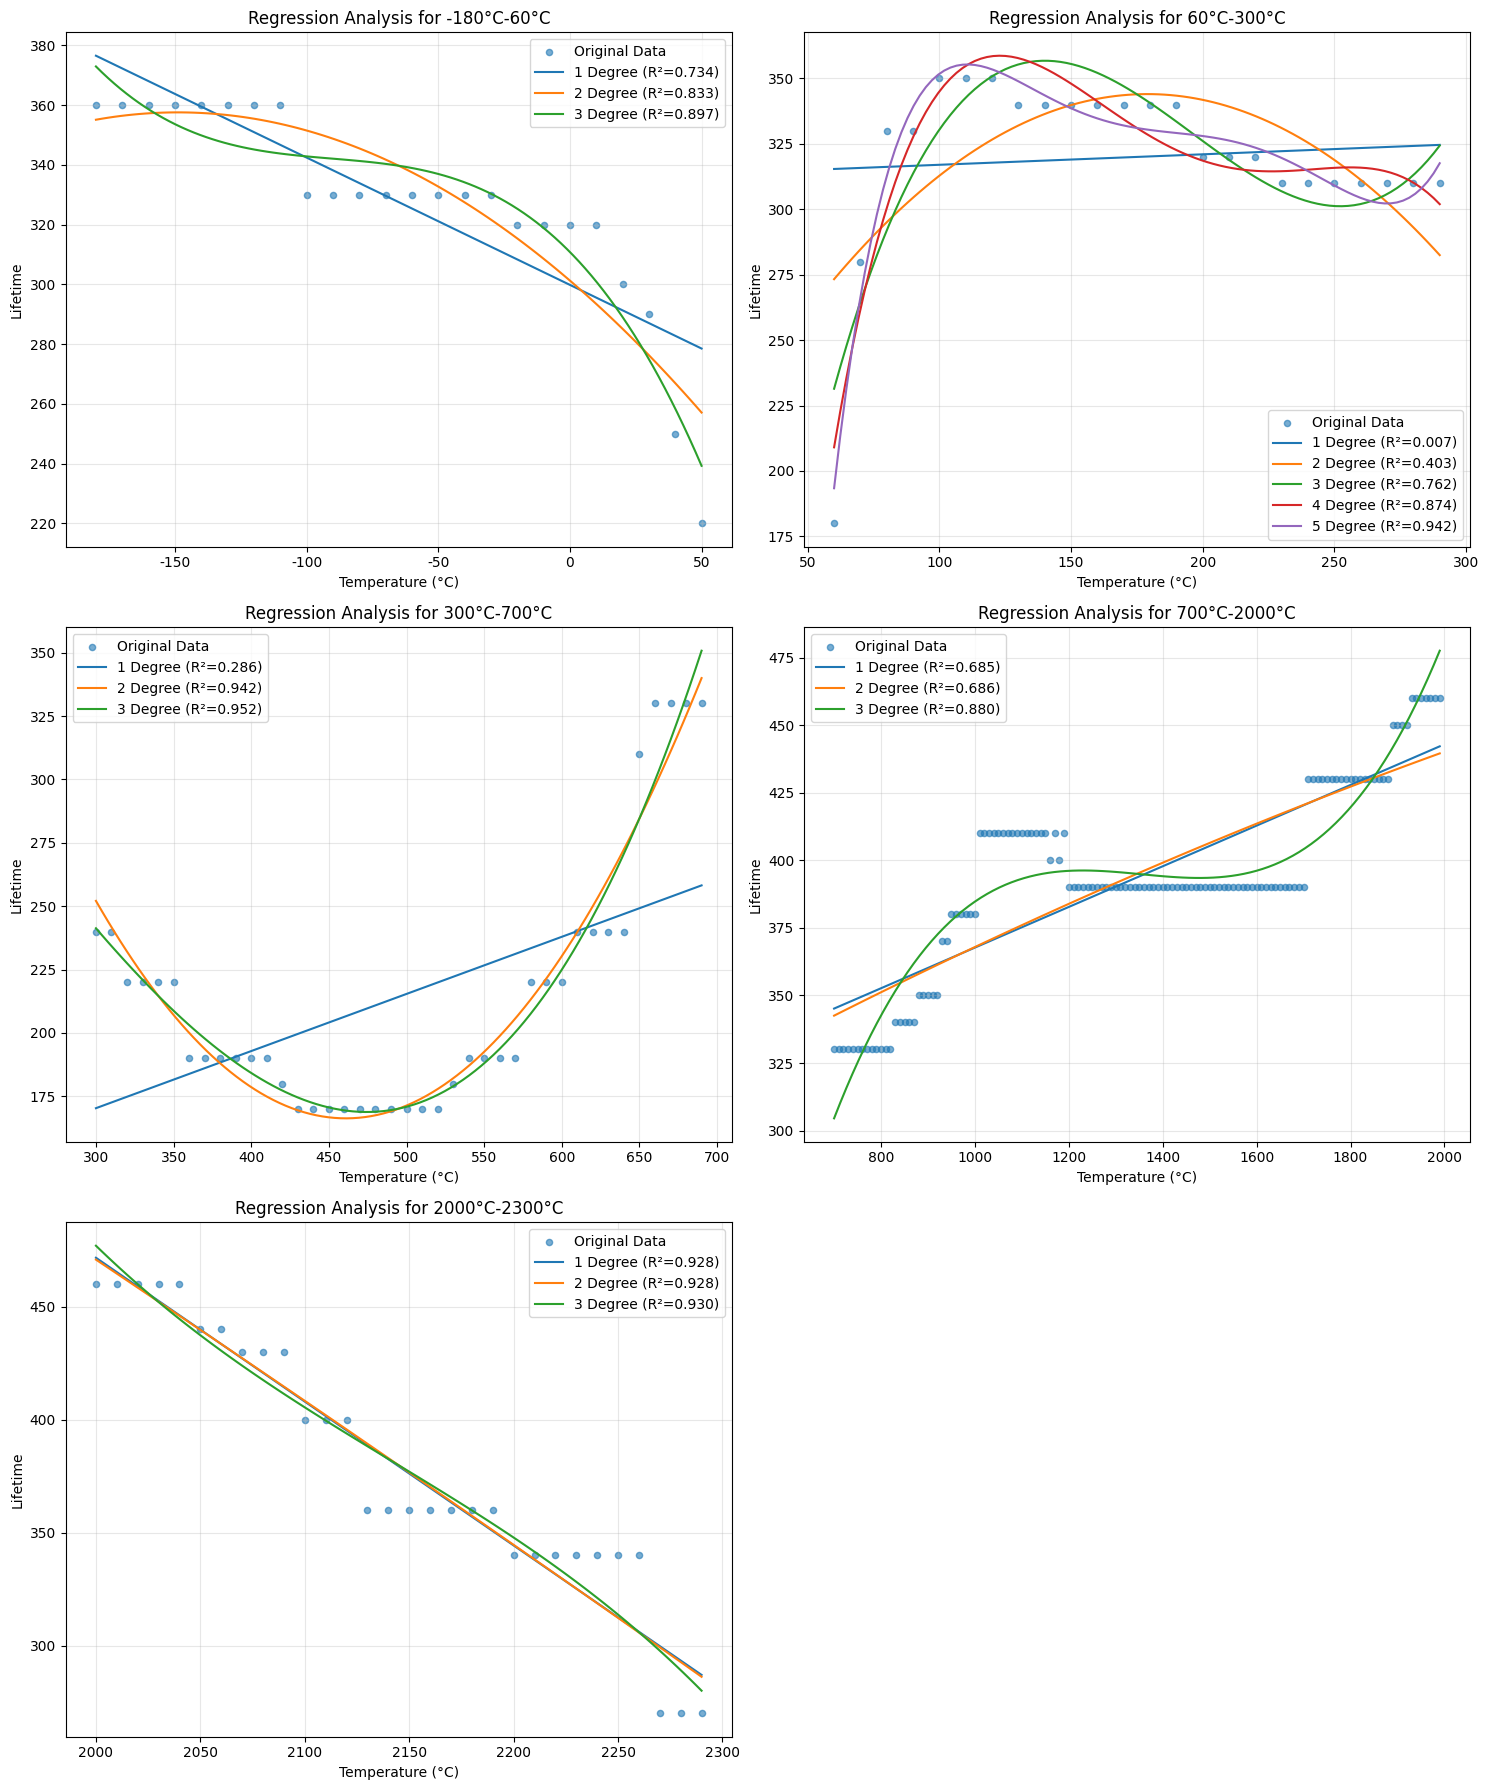

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from sklearn.metrics import r2_score
from openpyxl import load_workbook

# 配置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ------------------ 数据准备阶段 ------------------
# 加载数据
wb = load_workbook("x1.xlsx", data_only=True)
ws = wb["Sheet5"]

# 创建DataFrame
data = []
for row in ws.iter_rows(min_row=2):
    try:
        data.append([float(cell.value) for cell in row[:3]])
    except:
        continue

df = pd.DataFrame(data, columns=["Temperature", "Mass Fraction", "Lifetime"])
df = df.sort_values("Temperature").reset_index(drop=True)

# ------------------ 分段回归分析 ------------------
# 定义温度区间（可调整）
segments = [
    (-180, 60),
    (60, 300),
    (300, 700),
    (700, 2000),
    (2000, 2300)
]

# 存储回归结果
results = []
plt.figure(figsize=(15, 18))

# 遍历每个温度区间
for idx, (start, end) in enumerate(segments, 1):
    # 提取区间数据
    mask = (df["Temperature"] >= start) & (df["Temperature"] < end)
    segment_df = df[mask].copy()
    
    if len(segment_df) < 10:  # 数据量不足跳过
        continue
    
    # 准备回归数据
    X = segment_df["Temperature"].values
    y = segment_df["Lifetime"].values
    
    # 创建子图
    ax = plt.subplot(3, 2, idx)
    ax.scatter(X, y, s=20, alpha=0.6, label='Original Data')
    
    # 尝试不同阶次回归
    best_r2 = -np.inf
    best_model = None
    
    # 对于60-300区间，增加4次和5次多项式
    if (start, end) == (60, 300):
        degrees_to_try = [1, 2, 3, 4, 5]
    else:
        degrees_to_try = [1, 2, 3]
    
    for degree in degrees_to_try:
        try:
            coeffs = np.polyfit(X, y, degree)
            model = np.poly1d(coeffs)
            y_pred = model(X)
            current_r2 = r2_score(y, y_pred)
            
            # 可视化拟合曲线
            x_plot = np.linspace(X.min(), X.max(), 100)
            ax.plot(x_plot, model(x_plot), 
                   label=f'{degree} Degree (R²={current_r2:.3f})')
            
            # 记录最佳模型
            if current_r2 > best_r2:
                best_r2 = current_r2
                best_model = {
                    'degree': degree,
                    'coeffs': coeffs,
                    'r2': current_r2
                }
                
        except Exception as e:
            print(f"Fitting failed for range {start}-{end} at degree {degree}: {str(e)}")
    
    # 记录结果
    results.append({
        'Range': f"{start}°C-{end}°C",
        'Data Points': len(X),
        'Best Degree': best_model['degree'],
        'Coefficients': best_model['coeffs'],
        'R²': best_model['r2']
    })
    
    # 图表装饰
    ax.set_title(f'Regression Analysis for {start}°C-{end}°C')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Lifetime')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Segmented_Regression_Analysis.png', dpi=300)

# ------------------ 预测与插值 ------------------
def format_equation(coeffs):
    """将系数转换为方程字符串"""
    terms = []
    for power, coeff in enumerate(coeffs[::-1]):
        if power == 0:
            term = f"{coeff:.4e}"
        else:
            term = f"{coeff:.4e}x^{power}"
        terms.append(term)
    return "y = " + " + ".join(terms)

# 输出回归结果
print("\n=== Segmented Regression Results ===")
result_df = pd.DataFrame(results)
for _, row in result_df.iterrows():
    print(f"\nRange: {row['Range']}")
    print(f"Data Points: {row['Data Points']}")
    print(f"Best Polynomial Degree: {row['Best Degree']}")
    print(f"Regression Equation: {format_equation(row['Coefficients'])}")
    print(f"R² Value: {row['R²']:.4f}")

# 示例预测温度
predict_temp = 500
print(f"\n=== Prediction at {predict_temp}°C ===")

# 方法1：插值法（三次样条）
try:
    spline = interpolate.interp1d(df["Temperature"], df["Lifetime"], kind='cubic')
    interp_value = spline(predict_temp)
    print(f"Interpolation Prediction: {interp_value:.2f}")
except:
    interp_value = np.nan

# 方法2：回归预测
for seg in results:
    start, end = map(int, seg['Range'].split('°C-'))
    if start <= predict_temp < end:
        model = np.poly1d(seg['Coefficients'])
        regress_value = model(predict_temp)
        print(f"Regression Prediction ({seg['Range']}): {regress_value:.2f}")
        break

# ------------------ 综合可视化 ------------------
plt.figure(figsize=(12, 6))
plt.scatter(df["Temperature"], df["Lifetime"], s=15, alpha=0.6, label='Original Data')

# 绘制全区间回归曲线
for seg in results:
    coeffs = seg['Coefficients']
    model = np.poly1d(coeffs)
    start, end = map(int, seg['Range'].split('°C-'))
    x_range = np.linspace(start, end, 100)
    plt.plot(x_range, model(x_range), 
            linewidth=2,
            label=f'{seg["Range"]}\n{format_equation(coeffs)}')

plt.title("Lifetime Regression Analysis Across Temperature Ranges")
plt.xlabel("Temperature (°C)")
plt.ylabel("Lifetime")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Comprehensive_Regression_Analysis.png', dpi=300, bbox_inches='tight')

# ------------------ 结果保存 ------------------
# 保存回归结果到Excel
with pd.ExcelWriter('x1_analysis.xlsx') as writer:
    result_df.to_excel(writer, sheet_name='Regression_Analysis', index=False)
    df.to_excel(writer, sheet_name='Original_Data', index=False)

print("\nProcessing completed! Results saved to:")
print("- Segmented_Regression_Analysis.png")
print("- Comprehensive_Regression_Analysis.png")
print("- x1_analysis.xlsx")

# 关闭工作簿
wb.close()
plt.show()    

In [28]:
import openpyxl
from openpyxl.utils import get_column_letter
import bisect
import sys

def read_group_data(sheet, start_col):
    """读取两列组成的数据组"""
    # 检查第一行温度值
    temp1 = sheet.cell(row=1, column=start_col).value
    temp2 = sheet.cell(row=1, column=start_col+1).value
    
    try:
        temp1 = float(temp1)
        temp2 = float(temp2)
    except TypeError:
        print(f"错误：第{start_col}和{start_col+1}列的温度值不是有效数字")
        sys.exit(1)
    
    if abs(temp1 - temp2) > 1e-6:  # 允许浮点数微小误差
        print(f"错误：第{start_col}列温度{temp1}与第{start_col+1}列温度{temp2}不相等")
        sys.exit(1)
    
    temperature = round((temp1 + temp2) / 2, 2)  # 取平均值并保留两位小数
    
    # 读取数据
    time_data = []
    weight_data = []
    row = 3
    while True:
        time_val = sheet.cell(row=row, column=start_col).value
        weight_val = sheet.cell(row=row, column=start_col+1).value
        
        if time_val is None and weight_val is None:
            break
        
        try:
            time_data.append(float(time_val))
            weight_data.append(float(weight_val))
        except TypeError:
            break  # 遇到空值停止读取
        
        row += 1
    
    return {
        'temp': temperature,
        'time': time_data,
        'weight': weight_data,
        'length': len(time_data)
    }

# 读取原始数据
wb = openpyxl.load_workbook('x1.xlsx')
sheet6 = wb['Sheet6']

# 解析所有数据组
original_groups = []
max_col = sheet6.max_column

for col in range(1, max_col, 2):
    if col+1 > max_col:
        break
    group_data = read_group_data(sheet6, col)
    original_groups.append(group_data)

# 按温度排序原始数据
original_groups.sort(key=lambda x: x['temp'])
temps = [g['temp'] for g in original_groups]

# 生成目标温度列表
target_temps = [t for t in range(1300, 1900, 10)]

# 数据增强处理
enhanced_data = []
for target_temp in target_temps:
    # 寻找相邻温度索引
    idx = bisect.bisect_left(temps, target_temp)
    
    # 边界情况处理
    if idx == 0:
        if target_temp < temps[0]:
            continue  # 忽略低于最小温度的数据
        else:
            prev = original_groups[0]
            next = original_groups[0]
    elif idx == len(temps):
        prev = original_groups[-1]
        next = original_groups[-1]
    else:
        prev = original_groups[idx-1]
        next = original_groups[idx]
    
    # 确定有效长度
    valid_length = min(prev['length'], next['length'])
    
    # 当目标温度已存在时直接使用现有数据
    if abs(prev['temp'] - target_temp) < 1e-6:
        enhanced_data.append({
            'temp': target_temp,
            'time': prev['time'][:valid_length],
            'weight': prev['weight'][:valid_length]
        })
        continue
    
    # 线性插值处理
    interpolated = []
    for i in range(valid_length):
        ratio = (target_temp - prev['temp']) / (next['temp'] - prev['temp'])
        w = prev['weight'][i] + ratio * (next['weight'][i] - prev['weight'][i])
        interpolated.append(w)
    
    enhanced_data.append({
        'temp': target_temp,
        'time': prev['time'][:valid_length],  # 使用前一个温度的时间序列
        'weight': interpolated
    })

# 处理输出工作表
if 'Sheet7' in wb.sheetnames:
    wb.remove(wb['Sheet7'])
sheet7 = wb.create_sheet('Sheet7', 7)  

# 写入增强数据
current_col = 1
for data in enhanced_data:
    # 写入温度（合并单元格）
    sheet7.cell(1, current_col, data['temp'])
    sheet7.cell(1, current_col+1, data['temp'])
    
    # 写表头
    sheet7.cell(2, current_col, '时间')
    sheet7.cell(2, current_col+1, '重量')
    
    # 写数据
    for i in range(len(data['time'])):
        sheet7.cell(i+3, current_col, data['time'][i])
        sheet7.cell(i+3, current_col+1, data['weight'][i])
    
    current_col += 2

# 保存文件
wb.save('x1.xlsx')
print("数据处理完成，结果已保存到Sheet7")

数据处理完成，结果已保存到Sheet7


In [29]:
import pandas as pd
import numpy as np

# 文件路径
file_path = "x1.xlsx"

# ========== 复制Sheet7到Sheet8 ==========
try:
    df_sheet7 = pd.read_excel(file_path, sheet_name="Sheet7", header=None)
    with pd.ExcelWriter(file_path, mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
        df_sheet7.to_excel(writer, sheet_name="Sheet8", index=False, header=False)
except Exception as e:
    print(f"复制Sheet7时出错：{str(e)}")
    exit()

# ========== 处理Sheet8 ==========
try:
    df = pd.read_excel(file_path, sheet_name="Sheet8", header=None)
    
    stop_flag = False
    
    # 遍历所有偶数列（按Python索引0开始）
    for col in range(1, df.shape[1], 2):
        # 获取第一行温度值
        temp_value = df.iloc[0, col]
        
        # ========== 打印前三行信息 ==========
        print(f"\n正在处理第{col+1}列（编程索引{col}）")
        print("[首行温度]", temp_value)
        print("[表头]", df.iloc[1, col])
        print("[初始重量]", df.iloc[2, col])
        
        # ========== 终止条件检查 ==========
        if temp_value == 1900:
            stop_flag = True
            print("检测到1900℃，处理完当前列后终止")
        
        # ========== 数据处理逻辑 ==========
        try:
            initial_weight = float(df.iloc[2, col])
        except:
            print(f"第{col+1}列第三行数据无效，跳过处理")
            continue
        
        consecutive_empty = 0
        for row in range(3, df.shape[0]):  # 从第四行开始
            current_val = df.iat[row, col]
            
            # 检测连续空值
            if pd.isna(current_val):
                consecutive_empty += 1
                if consecutive_empty >= 3:
                    print(f"在第{row+1}行检测到连续3个空值，停止处理本列")
                    break
            else:
                consecutive_empty = 0
                try:
                    # 计算差值并保留6位小数
                    new_val = round(float(current_val) - initial_weight, 6)
                    df.iat[row, col] = new_val
                except:
                    df.iat[row, col] = np.nan
        
        # ========== 终止执行检查 ==========
        if stop_flag:
            print("已处理1900℃列，终止程序")
            break

    # ========== 保存修改后的数据 ==========
    with pd.ExcelWriter(file_path, mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
        df.to_excel(writer, sheet_name="Sheet8", index=False, header=False)
        
except Exception as e:
    print(f"处理Sheet8时出错：{str(e)}")
    exit()

print("\n数据处理完成！结果已保存至Sheet8")


正在处理第2列（编程索引1）
[首行温度] 1300
[表头] 重量
[初始重量] 7.5203

正在处理第4列（编程索引3）
[首行温度] 1310
[表头] 重量
[初始重量] 7.517553333333333
在第46行检测到连续3个空值，停止处理本列

正在处理第6列（编程索引5）
[首行温度] 1320
[表头] 重量
[初始重量] 7.514806666666667
在第46行检测到连续3个空值，停止处理本列

正在处理第8列（编程索引7）
[首行温度] 1330
[表头] 重量
[初始重量] 7.51206
在第46行检测到连续3个空值，停止处理本列

正在处理第10列（编程索引9）
[首行温度] 1340
[表头] 重量
[初始重量] 7.509313333333333
在第46行检测到连续3个空值，停止处理本列

正在处理第12列（编程索引11）
[首行温度] 1350
[表头] 重量
[初始重量] 7.506566666666666
在第46行检测到连续3个空值，停止处理本列

正在处理第14列（编程索引13）
[首行温度] 1360
[表头] 重量
[初始重量] 7.50382
在第46行检测到连续3个空值，停止处理本列

正在处理第16列（编程索引15）
[首行温度] 1370
[表头] 重量
[初始重量] 7.501073333333333
在第46行检测到连续3个空值，停止处理本列

正在处理第18列（编程索引17）
[首行温度] 1380
[表头] 重量
[初始重量] 7.498326666666666
在第46行检测到连续3个空值，停止处理本列

正在处理第20列（编程索引19）
[首行温度] 1390
[表头] 重量
[初始重量] 7.495579999999999
在第46行检测到连续3个空值，停止处理本列

正在处理第22列（编程索引21）
[首行温度] 1400
[表头] 重量
[初始重量] 7.492833333333333
在第46行检测到连续3个空值，停止处理本列

正在处理第24列（编程索引23）
[首行温度] 1410
[表头] 重量
[初始重量] 7.490086666666667
在第46行检测到连续3个空值，停止处理本列

正在处理第26列（编程索引25）
[首行温度] 1420
[表头] 重量
[初始重

In [33]:
import pandas as pd
import numpy as np

# 文件路径
file_path = "x1.xlsx"

# ========== 复制Sheet8到Sheet9 ==========
try:
    # 读取Sheet8数据
    df_sheet8 = pd.read_excel(file_path, sheet_name="Sheet8", header=None)
    
    # 写入Sheet9（覆盖模式）
    with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
        df_sheet8.to_excel(writer, sheet_name='Sheet9', index=False, header=False)
except Exception as e:
    print(f"复制Sheet8时出错：{str(e)}")
    exit()

# ========== 处理Sheet9数据 ==========
try:
    # 读取Sheet9数据
    df = pd.read_excel(file_path, sheet_name='Sheet9', header=None)
    
    # 处理参数
    min_temp = 1610
    max_temp = 1900
    step = 10
    modified_cols = []

    # 遍历列组
    for col in range(0, df.shape[1], 2):
        if col+1 >= df.shape[1]:
            break

        # 验证温度一致性
        try:
            temp = int(df.iloc[0, col])
            if df.iloc[0, col] != df.iloc[0, col+1]:
                continue
            if not (min_temp <= temp <= max_temp):
                continue
            if (temp - min_temp) % step != 0:
                continue
        except:
            continue

        print(f"处理温度 {temp}℃ (列{col+1})")
        
        # 计算缩放系数
        A = 1 + (1900 - temp) * 0.0023
        print(f"温度差：{1900-temp}℃，缩放系数：{A:.4f}")

        # 处理时间列数据（从第4行开始）
        for row in range(3, df.shape[0]):
            original_val = df.iat[row, col]
            if pd.isna(original_val):
                continue
            try:
                new_val = float(original_val) * A
                df.iat[row, col] = round(new_val, 6)
            except:
                df.iat[row, col] = np.nan

        modified_cols.append(col)

    # 保存修改后的Sheet9
    if modified_cols:
        with pd.ExcelWriter(
            file_path,
            engine='openpyxl',
            mode='a',
            if_sheet_exists='replace'
        ) as writer:
            df.to_excel(writer, sheet_name='Sheet9', index=False, header=False)
        print(f"\n成功处理 {len(modified_cols)} 组数据列")
    else:
        print("\n未找到符合条件的数据列")

except Exception as e:
    print(f"处理Sheet9时出错：{str(e)}")
    exit()

print("处理完成！数据已更新至Sheet9")

处理温度 1610℃ (列63)
温度差：290℃，缩放系数：1.6670
处理温度 1620℃ (列65)
温度差：280℃，缩放系数：1.6440
处理温度 1630℃ (列67)
温度差：270℃，缩放系数：1.6210
处理温度 1640℃ (列69)
温度差：260℃，缩放系数：1.5980
处理温度 1650℃ (列71)
温度差：250℃，缩放系数：1.5750
处理温度 1660℃ (列73)
温度差：240℃，缩放系数：1.5520
处理温度 1670℃ (列75)
温度差：230℃，缩放系数：1.5290
处理温度 1680℃ (列77)
温度差：220℃，缩放系数：1.5060
处理温度 1690℃ (列79)
温度差：210℃，缩放系数：1.4830
处理温度 1700℃ (列81)
温度差：200℃，缩放系数：1.4600
处理温度 1710℃ (列83)
温度差：190℃，缩放系数：1.4370
处理温度 1720℃ (列85)
温度差：180℃，缩放系数：1.4140
处理温度 1730℃ (列87)
温度差：170℃，缩放系数：1.3910
处理温度 1740℃ (列89)
温度差：160℃，缩放系数：1.3680
处理温度 1750℃ (列91)
温度差：150℃，缩放系数：1.3450
处理温度 1760℃ (列93)
温度差：140℃，缩放系数：1.3220
处理温度 1770℃ (列95)
温度差：130℃，缩放系数：1.2990
处理温度 1780℃ (列97)
温度差：120℃，缩放系数：1.2760
处理温度 1790℃ (列99)
温度差：110℃，缩放系数：1.2530
处理温度 1800℃ (列101)
温度差：100℃，缩放系数：1.2300
处理温度 1810℃ (列103)
温度差：90℃，缩放系数：1.2070
处理温度 1820℃ (列105)
温度差：80℃，缩放系数：1.1840
处理温度 1830℃ (列107)
温度差：70℃，缩放系数：1.1610
处理温度 1840℃ (列109)
温度差：60℃，缩放系数：1.1380
处理温度 1850℃ (列111)
温度差：50℃，缩放系数：1.1150
处理温度 1860℃ (列113)
温度差：40℃，缩放系数：1.0920
处理温度 1870℃ 

Initial database temperatures: [1300, 1450, 1600, 1900]
Low temperature range (16 points): [1300, 1310, 1320, 1330, 1340, 1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420, 1430, 1440, 1450]
High temperature range (10 points): [1450, 1500, 1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900]


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

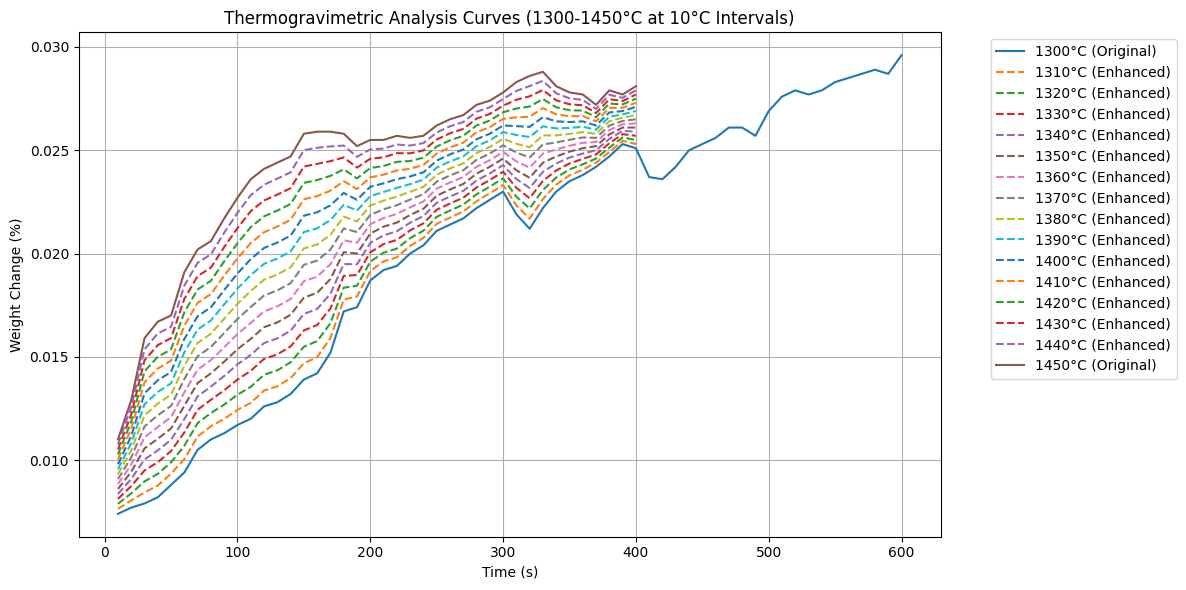

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

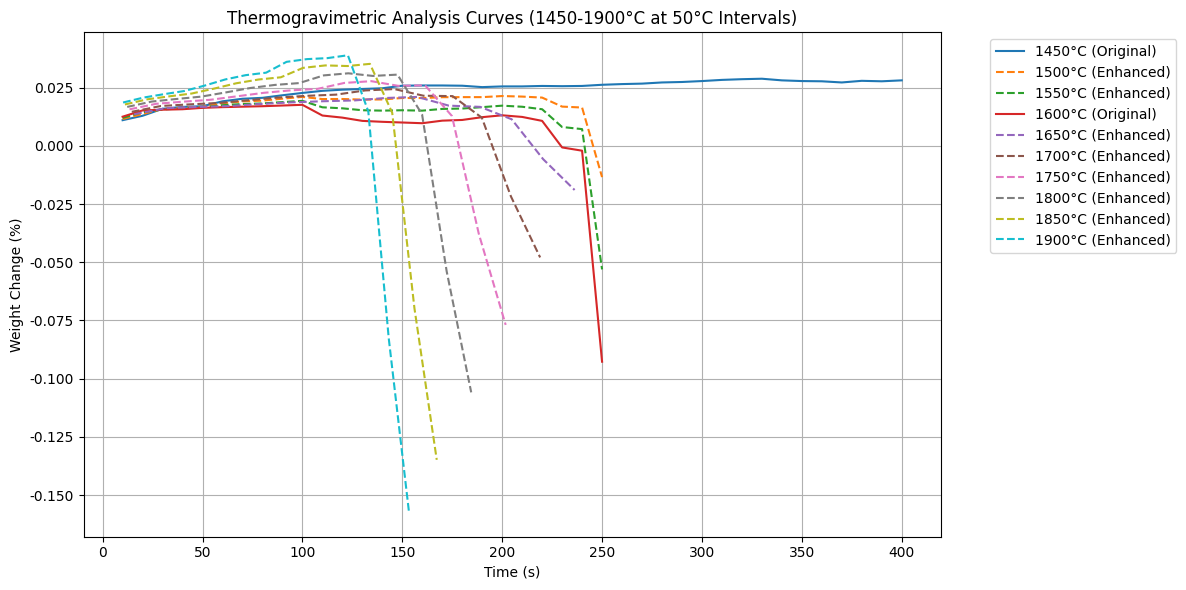

Chart display completed


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ========== 读取初始数据 ==========
def read_initial_temps():
    df_sheet6 = pd.read_excel('x1.xlsx', sheet_name='Sheet6', header=None)
    return set(df_sheet6.iloc[0].dropna().astype(int).tolist())

initial_temps = read_initial_temps()
print("Initial database temperatures:", sorted(initial_temps))

# ========== 处理Sheet9数据 ==========
df_sheet9 = pd.read_excel('x1.xlsx', sheet_name='Sheet9', header=None)
data_groups = []

# 遍历所有列组
for col in range(0, df_sheet9.shape[1], 2):
    if col+1 >= df_sheet9.shape[1]:
        break
    
    # 验证温度一致性
    temp1 = df_sheet9.iloc[0, col]
    temp2 = df_sheet9.iloc[0, col+1]
    
    if temp1 != temp2:
        print(f"Temperatures do not match in columns {col}-{col+1}: {temp1} vs {temp2}")
        continue
    
    temp = int(temp1)
    time_data = df_sheet9.iloc[3:, col].dropna().values.astype(float)
    weight_data = df_sheet9.iloc[3:, col+1].dropna().values.astype(float)
    
    # 对齐数据长度
    min_len = min(len(time_data), len(weight_data))
    data_groups.append({
        'temperature': temp,
        'time': time_data[:min_len],
        'weight': weight_data[:min_len],
        'is_initial': temp in initial_temps
    })

# ========== 生成目标温度点 ==========
low_temp_range = list(range(1300, 1451, 10))  # 1300-1450℃ at 10℃ intervals
high_temp_range = list(range(1450, 1901, 50))  # 1450-1900℃ at 50℃ intervals
print("Low temperature range (16 points):", low_temp_range)
print("High temperature range (10 points):", high_temp_range)

# ========== 绘图函数 ==========
def plot_tga(data_groups, target_temps, title):
    plt.figure(figsize=(12, 6))
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Weight Change (%)")
    
    for temp in target_temps:
        # Find the closest temperature data
        closest = min(data_groups, key=lambda x: abs(x['temperature']-temp))
        
        # Set line style
        line_style = '-' if closest['is_initial'] else '--'
        
        # Plot the curve
        plt.plot(closest['time'], closest['weight'],
                 linestyle=line_style,
                 linewidth=1.5,
                 label=f"{temp}°C ({'Original' if closest['is_initial'] else 'Enhanced'})")
    
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ========== 绘制两个子图 ==========
plot_tga(data_groups, low_temp_range, "Thermogravimetric Analysis Curves (1300-1450°C at 10°C Intervals)")
plot_tga(data_groups, high_temp_range, "Thermogravimetric Analysis Curves (1450-1900°C at 50°C Intervals)")

print("Chart display completed")    

In [38]:
import pandas as pd
import numpy as np

def find_local_max(weight_series):
    # 反向遍历寻找第一个递减点前的极大值
    if len(weight_series) < 2:
        return np.nan, np.nan
    
    max_val = weight_series[-1]
    max_idx = len(weight_series) - 1
    
    for i in range(len(weight_series)-2, -1, -1):
        if weight_series[i] > max_val:
            max_val = weight_series[i]
            max_idx = i
        else:
            break  # 找到第一个递减点
    
    return max_val, max_idx

# ========== 主程序 ==========
file_path = "x1.xlsx"
result = []

try:
    # 读取Sheet9数据
    df = pd.read_excel(file_path, sheet_name="Sheet9", header=None)
    
    # 遍历所有列组
    for col in range(0, df.shape[1], 2):
        if col+1 >= df.shape[1]:
            continue
        
        # 验证温度一致性
        try:
            temp = int(df.iloc[0, col])
            if df.iloc[0, col] != df.iloc[0, col+1]:
                continue
            if not (1600 <= temp <= 1900):
                continue
            if (temp - 1600) % 10 != 0:
                continue
        except:
            continue
        
        print(f"处理温度 {temp}℃ (列{col+1}-{col+2})")
        
        # 获取有效数据
        time_data = df.iloc[3:, col].dropna().astype(float)
        weight_data = df.iloc[3:, col+1].dropna().astype(float)
        min_len = min(len(time_data), len(weight_data))
        
        if min_len < 3:
            print("  数据不足，跳过")
            continue
        
        # 处理质量列数据
        weight_values = weight_data[:min_len]
        time_values = time_data[:min_len]
        
        # 寻找局部极大值A和时间B
        A, max_idx = find_local_max(weight_values.values)
        B = time_values.iloc[max_idx] if not np.isnan(A) else np.nan
        
        # 寻找全局最大值C
        C = np.nanmax(weight_values)
        try:
            D = df.iloc[2, col+1]  # 第三行（索引2对应第四行）
            E = round(C / D, 6) if D != 0 else np.nan
        except:
            E = np.nan
        
        result.append({
            '温度(℃)': temp,
            'A(局部极大值)': A,
            'B(对应时间)': B,
            'C(最大值)': C,
            'D(初始值)': D,
            'E(比值)': E
        })

except Exception as e:
    print(f"读取数据出错：{str(e)}")
    exit()

# ========== 写入Sheet10 ==========
if result:
    result_df = pd.DataFrame(result)
    result_df = result_df.sort_values('温度(℃)').reset_index(drop=True)
    
    try:
        with pd.ExcelWriter(
            file_path,
            engine='openpyxl',
            mode='a',
            if_sheet_exists='replace'
        ) as writer:
            result_df.to_excel(writer, sheet_name='Sheet10', index=False)
        print(f"\n成功写入{len(result)}条数据到Sheet10")
    except Exception as e:
        print(f"写入文件出错：{str(e)}")
else:
    print("没有符合条件的数据")

print("处理完成！")

处理温度 1600℃ (列61-62)
处理温度 1610℃ (列63-64)
处理温度 1620℃ (列65-66)
处理温度 1630℃ (列67-68)
处理温度 1640℃ (列69-70)
处理温度 1650℃ (列71-72)
处理温度 1660℃ (列73-74)
处理温度 1670℃ (列75-76)
处理温度 1680℃ (列77-78)
处理温度 1690℃ (列79-80)
处理温度 1700℃ (列81-82)
处理温度 1710℃ (列83-84)
处理温度 1720℃ (列85-86)
处理温度 1730℃ (列87-88)
处理温度 1740℃ (列89-90)
处理温度 1750℃ (列91-92)
处理温度 1760℃ (列93-94)
处理温度 1770℃ (列95-96)
处理温度 1780℃ (列97-98)
处理温度 1790℃ (列99-100)
处理温度 1800℃ (列101-102)
处理温度 1810℃ (列103-104)
处理温度 1820℃ (列105-106)
处理温度 1830℃ (列107-108)
处理温度 1840℃ (列109-110)
处理温度 1850℃ (列111-112)
处理温度 1860℃ (列113-114)
处理温度 1870℃ (列115-116)
处理温度 1880℃ (列117-118)
处理温度 1890℃ (列119-120)

成功写入30条数据到Sheet10
处理完成！


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 配置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def polynomial_fit(x, y, degree):
    """多项式拟合函数"""
    try:
        if len(x) < degree + 1:
            raise ValueError("数据不足")
        coeffs = np.polyfit(x, y, degree)
        y_pred = np.polyval(coeffs, x)
        r2 = r2_score(y, y_pred)
        
        # 生成方程表达式
        equation = "y = "
        for i, c in enumerate(coeffs):
            power = degree - i
            if power == 0:
                equation += f"{c:.4e}"
            else:
                equation += f"{c:.4e}x^{power} + "
        return equation.rstrip(" + "), r2, coeffs
    except Exception as e:
        print(f"{degree}次拟合失败：{str(e)}")
        return None, None, None

# ========== 数据读取 ==========
try:
    df = pd.read_excel('x1.xlsx', sheet_name='Sheet10', header=0)
    data = df.iloc[1:, [0, 2, 5]].dropna().astype(float)  # A(0), C(2), E(4)列
    temperatures = data.iloc[:, 0].values
    peel_time = data.iloc[:, 1].values
    mass_ratio = data.iloc[:, 2].values
except Exception as e:
    print(f"数据读取失败：{str(e)}")
    exit()

# ========== 执行拟合分析 ==========
results = []

# 温度与脱落时间分析
plt.figure(figsize=(10, 6))
plt.scatter(temperatures, peel_time, color='blue', label='原始数据')

for degree in [1, 2, 3]:
    equation, r2, coeffs = polynomial_fit(temperatures, peel_time, degree)
    if equation:
        x_range = np.linspace(min(temperatures), max(temperatures), 100)
        y_fit = np.polyval(coeffs, x_range)
        plt.plot(x_range, y_fit, '--', label=f'{degree}次拟合 (R²={r2:.3f})')
        results.append({
            '关系类型': '温度-脱落时间',
            '次数': degree,
            '方程': equation,
            'R²值': r2,
            '系数': coeffs.tolist()
        })

plt.title('温度与脱落时间关系分析')
plt.xlabel('温度 (℃)')
plt.ylabel('脱落时间')
plt.legend()
plt.grid(True)
plt.savefig('温度-脱落时间拟合分析.png', dpi=300, bbox_inches='tight')
plt.close()

# 温度与质量比分析
plt.figure(figsize=(10, 6))
plt.scatter(temperatures, mass_ratio, color='green', label='原始数据')

for degree in [1, 2, 3]:
    equation, r2, coeffs = polynomial_fit(temperatures, mass_ratio, degree)
    if equation:
        x_range = np.linspace(min(temperatures), max(temperatures), 100)
        y_fit = np.polyval(coeffs, x_range)
        plt.plot(x_range, y_fit, '--', label=f'{degree}次拟合 (R²={r2:.3f})')
        results.append({
            '关系类型': '温度-质量比',
            '次数': degree,
            '方程': equation,
            'R²值': r2,
            '系数': coeffs.tolist()
        })

plt.title('温度与质量比关系分析')
plt.xlabel('温度 (℃)')
plt.ylabel('质量比')
plt.legend()
plt.grid(True)
plt.savefig('温度-质量比拟合分析.png', dpi=300, bbox_inches='tight')
plt.close()

# ========== 保存结果 ==========
if results:
    result_df = pd.DataFrame(results)
    try:
        with pd.ExcelWriter('x1.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            result_df.to_excel(writer, sheet_name='拟合结果', index=False)
        print("结果已保存到工作簿的【拟合结果】工作表")
        print("生成图表：")
        print("- 温度-脱落时间拟合分析.png")
        print("- 温度-质量比拟合分析.png")
    except Exception as e:
        print(f"保存失败：{str(e)}")
else:
    print("没有生成有效拟合结果")

print("处理完成")

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_486/813675414.py:69: UserWarning: Glyph 33073 (\N{CJK UNIFIED IDEOGRAPH-8131}) missing from font(s) DejaVu Sans.
  plt.savefig('温度-脱落时间拟合分析.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_486/813675414.py:69: UserWarning: Glyph 33853 (\N{CJ

结果已保存到工作簿的【拟合结果】工作表
生成图表：
- 温度-脱落时间拟合分析.png
- 温度-质量比拟合分析.png
处理完成


预测Z值（A=1900, C=120）: 436.8000


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

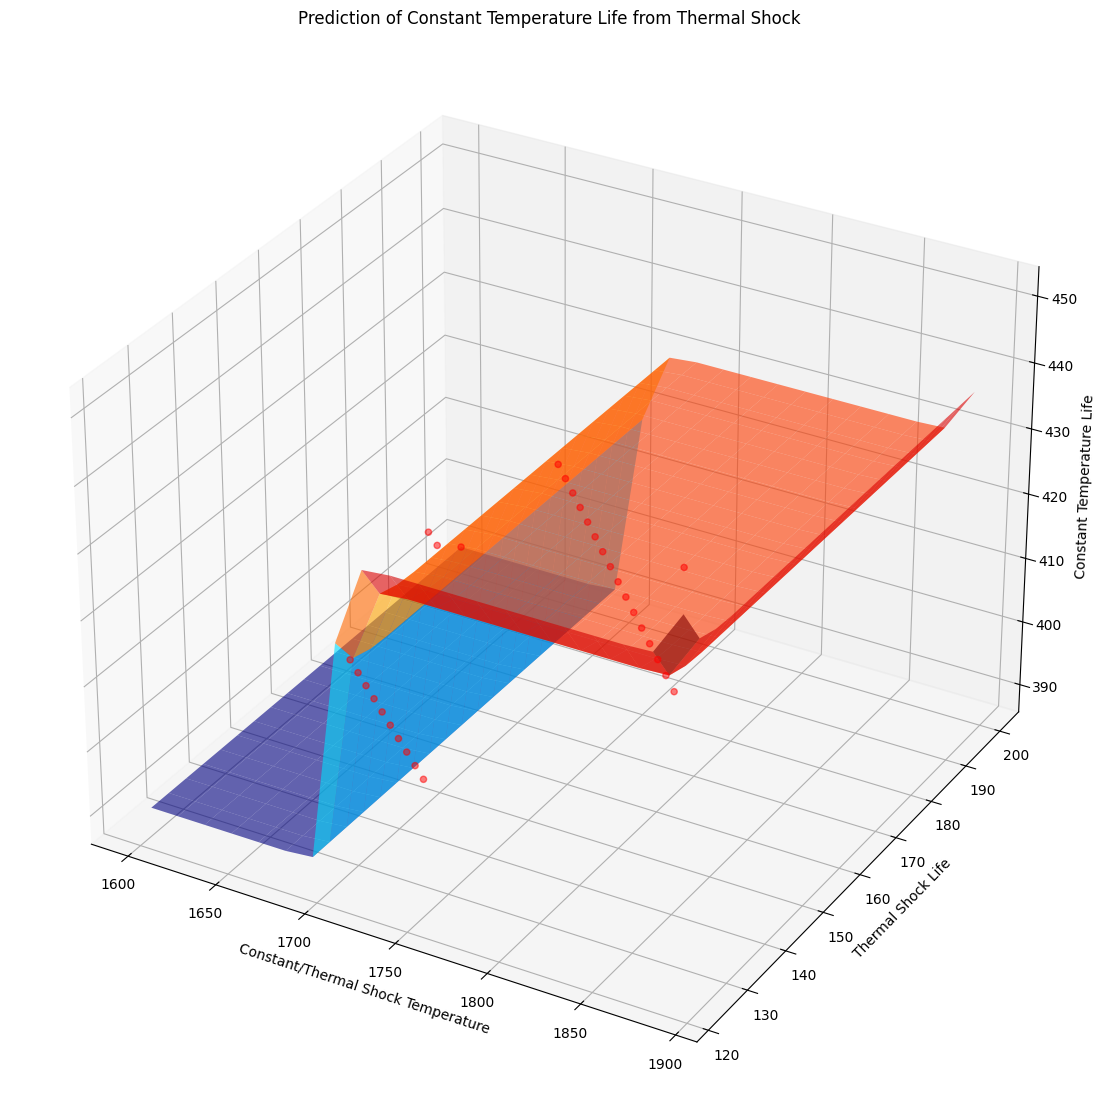

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

预测F值（B=1.7252）: 0.5114


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

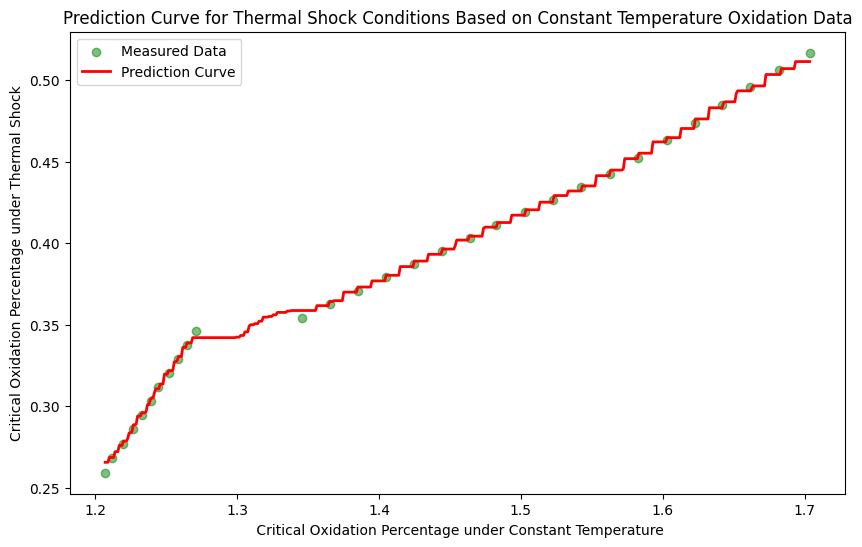

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from mpl_toolkits.mplot3d import Axes3D

# 读取数据
df = pd.read_excel('x1.xlsx', sheet_name='Sheet13')

# ========================== 第一部分：D列预测 ==========================
# 准备数据
X_d = df[['A', 'D']].values
y_d = df['C'].values

# 训练随机森林模型
model_d = RandomForestRegressor(n_estimators=100, random_state=42)
model_d.fit(X_d, y_d)

# 预测示例
z_pred = model_d.predict([[1900, 444.8626]])[0]
print(f'预测Z值（A=1900, C=120）: {z_pred:.4f}')

# 生成三维可视化
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

# 创建预测网格
a_space = np.linspace(df['A'].min(), df['A'].max(), 20)
c_space = np.linspace(df['D'].min(), df['D'].max(), 20)
A, C = np.meshgrid(a_space, c_space)
Z = model_d.predict(np.c_[A.ravel(), C.ravel()]).reshape(A.shape)

# 绘制图形
ax.scatter(df['A'], df['D'], df['C'], c='r', marker='o', alpha=0.5, label='实际数据')
ax.plot_surface(A, C, Z, alpha=0.6, cmap='jet', label='预测曲面')
ax.set_xlabel('Constant/Thermal Shock Temperature')
ax.set_ylabel('Thermal Shock Life')
ax.set_zlabel('Constant Temperature Life')
ax.set_title('Prediction of Constant Temperature Life from Thermal Shock')
plt.show()

# ========================== 第二部分：F列预测 ==========================
# 准备数据
X_f = df[['B']].values
y_f = df['F'].values

# 训练模型
model_f = RandomForestRegressor(n_estimators=100, random_state=42)
model_f.fit(X_f, y_f)

# 预测示例
f_pred = model_f.predict([[1.7252]])[0]
print(f'预测F值（B=1.7252）: {f_pred:.4f}')

# 生成可视化
plt.figure(figsize=(10, 6))

# 生成平滑预测曲线
b_space = np.linspace(df['B'].min(), df['B'].max(), 500).reshape(-1, 1)
f_pred_curve = model_f.predict(b_space)

plt.scatter(df['B'], df['F'], c='g', alpha=0.5, label='Measured Data')
plt.plot(b_space, f_pred_curve, 'r-', linewidth=2, label='Prediction Curve')
plt.xlabel(' Critical Oxidation Percentage under Constant Temperature')
plt.ylabel('Critical Oxidation Percentage under Thermal Shock')
plt.title('Prediction Curve for Thermal Shock Conditions Based on Constant Temperature Oxidation Data')
plt.legend()
plt.show()

/home/zyq0416/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/zyq0416/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


当 A 列值为 1900，C 列值为 450 时，预测 D 列值为: 130.00193662864393
当 B 列值为 1.7252 时，预测 F 列值为: 0.5223133720588102


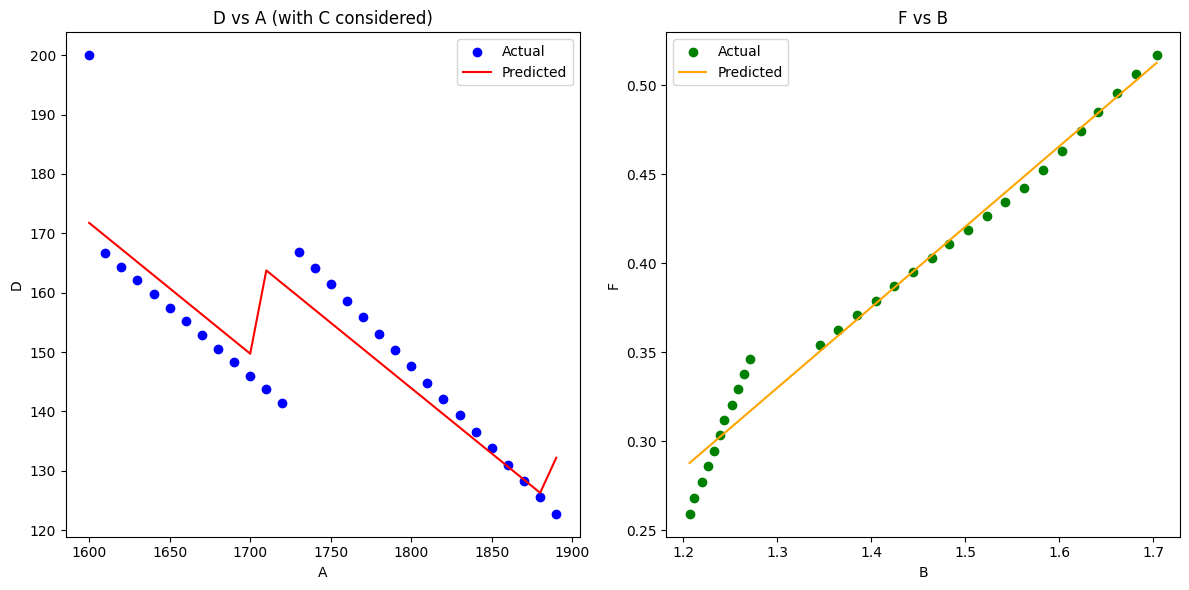

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


# 读取 Excel 文件
try:
    file_path = 'x1.xlsx'
    df = pd.read_excel(file_path, sheet_name='Sheet13')
except FileNotFoundError:
    print(f"错误: 文件 {file_path} 未找到。")
except Exception as e:
    print(f"错误: 读取文件时发生未知错误: {e}")
else:
    # 求出 D 列随 A 列与 C 列的变化关系
    X1 = df[['A', 'C']]
    y1 = df['D']
    model1 = LinearRegression()
    model1.fit(X1, y1)

    # 预测 D 列值
    X_pred1 = np.array([[1900, 450]])
    Z_pred = model1.predict(X_pred1)
    print(f"当 A 列值为 1900，C 列值为 450 时，预测 D 列值为: {Z_pred[0]}")

    # 绘制预测图像（这里以 A 列为例）
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(df['A'], y1, color='blue', label='Actual')
    plt.plot(df['A'], model1.predict(X1), color='red', label='Predicted')
    plt.xlabel('A')
    plt.ylabel('D')
    plt.title('D vs A (with C considered)')
    plt.legend()

    # 求出 F 列随 B 列的变化关系
    X2 = df[['B']]
    y2 = df['F']
    model2 = LinearRegression()
    model2.fit(X2, y2)

    # 预测 F 列值
    X_pred2 = np.array([[1.7252]])
    F_pred = model2.predict(X_pred2)
    print(f"当 B 列值为 1.7252 时，预测 F 列值为: {F_pred[0]}")

    # 绘制预测图像
    plt.subplot(1, 2, 2)
    plt.scatter(df['B'], y2, color='green', label='Actual')
    plt.plot(df['B'], model2.predict(X2), color='orange', label='Predicted')
    plt.xlabel('B')
    plt.ylabel('F')
    plt.title('F vs B')
    plt.legend()

    plt.tight_layout()
    plt.show()
    

In [3]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from openpyxl import load_workbook

def process_thermal_shock_data():
    # 读取原始数据
    file_path = 'x1.xlsx'
    sheet_name = 'Sheet11'
    
    try:
        # 读取原始数据（不设置header以保留所有原始格式）
        df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    except Exception as e:
        raise ValueError(f"读取Excel文件失败: {str(e)}")

    # 验证数据分组并提取有效温度
    valid_temps = []
    original_data = []
    
    for col in range(0, df.shape[1], 2):
        if col+1 >= df.shape[1]:
            break
        
        # 检查温度值是否一致
        temp1 = df.iloc[0, col]
        temp2 = df.iloc[0, col+1]
        if temp1 != temp2:
            raise ValueError(f"列{col+1}和{col+2}的温度值不匹配: {temp1} vs {temp2}")
        
        # 提取有效数据
        temp = float(temp1)
        time_data = df.iloc[2:, col].dropna().astype(float).values
        weight_data = df.iloc[2:, col+1].dropna().astype(float).values
        
        valid_temps.append(temp)
        original_data.append((temp, time_data, weight_data))

    # 生成目标温度范围
    target_temps = np.arange(1000, 1201, 10)
    
    # 创建统一时间轴
    all_times = np.unique(np.concatenate([d[1] for d in original_data]))
    all_times.sort()

    # 创建插值矩阵
    weight_matrix = pd.DataFrame(index=all_times)
    for temp, times, weights in original_data:
        # 对每个温度的数据进行时间插值
        f = interp1d(times, weights, kind='linear', fill_value='extrapolate')
        weight_matrix[temp] = f(all_times)

    # 执行温度维度插值
    enhanced = []
    for target_temp in target_temps:
        temp_weights = []
        for t in all_times:
            valid = weight_matrix.loc[t].dropna()
            if len(valid) < 2:
                # 如果可用数据不足，使用最近邻插值
                nearest_temp = valid.index[np.argmin(np.abs(valid.index - target_temp))]
                w = valid[nearest_temp]
            else:
                # 线性插值
                f_temp = interp1d(valid.index, valid.values, kind='linear', fill_value='extrapolate')
                w = f_temp(target_temp)
            
            # 添加随机扰动
            w += np.random.uniform(-0.0001, 0.0001)
            temp_weights.append(w)
        
        enhanced.append((target_temp, all_times, np.array(temp_weights)))

    # 构建增强后DataFrame
    output_rows = []
    
    # 添加温度行
    temp_row = []
    header_row = []
    for temp, _, _ in enhanced:
        temp_row.extend([temp, temp])
        header_row.extend(['时间', '重量'])
    
    output_rows.append(temp_row)
    output_rows.append(header_row)

    # 添加数据行
    max_length = max(len(times) for _, times, _ in enhanced)
    for i in range(max_length):
        row = []
        for temp, times, weights in enhanced:
            if i < len(times):
                row.extend([times[i], weights[i]])
            else:
                row.extend([np.nan, np.nan])
        output_rows.append(row)
    
    enhanced_df = pd.DataFrame(output_rows)

    # 保存增强数据
    with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        enhanced_df.to_excel(writer, sheet_name='Sheet12', index=False, header=False)

    # 处理斜率计算
    wb = load_workbook(file_path)
    if 'Sheet12' in wb.sheetnames:
        ws = wb['Sheet12']
    else:
        ws = wb.create_sheet('Sheet12')

    # 遍历每组数据
    for col in range(0, enhanced_df.shape[1], 2):
        if col+1 >= enhanced_df.shape[1]:
            break
        
        # 提取有效数据
        times = []
        weights = []
        for row in range(2, enhanced_df.shape[0]):
            try:
                t = float(enhanced_df.iloc[row, col])
                w = float(enhanced_df.iloc[row, col+1])
                times.append(t)
                weights.append(w)
            except:
                break
        
        if len(times) < 2:
            continue
        
        # 计算斜率
        slope = np.polyfit(times, weights, 1)[0]
        
        # 寻找时间=100的行
        found = False
        for idx, t in enumerate(times):
            if abs(t - 100) < 1e-6:
                # 在Excel行号中需要+3（0-based增强_df索引+2，Excel行号从1开始）
                target_row = idx + 3 + 1  # +1表示下一行
                ws.cell(row=target_row, column=col+1, value=slope)
                found = True
                break
        
        if not found:
            print(f"警告：第{col//2+1}组数据未找到时间=100的记录")

    wb.save(file_path)
    wb.close()

if __name__ == "__main__":
    process_thermal_shock_data()

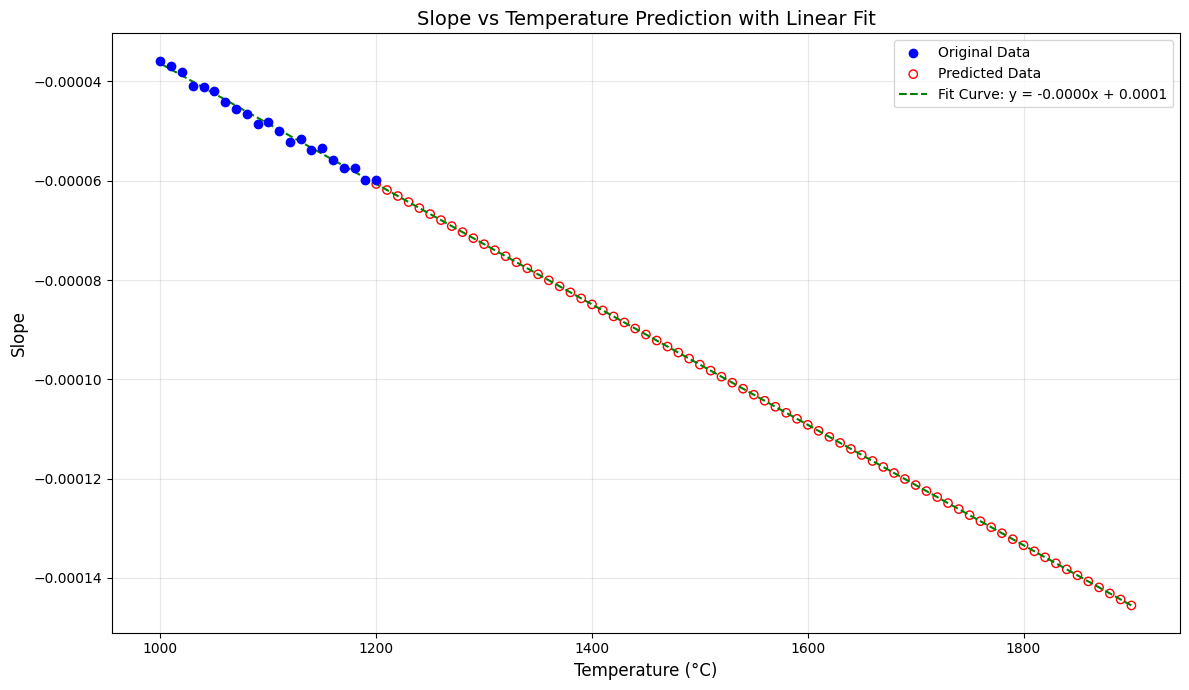

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 读取数据
file_path = "x1.xlsx"
sheet_name = "Sheet12"

# 读取奇数列数据（A,C,E...AO）
df = pd.read_excel(file_path, 
                  sheet_name=sheet_name, 
                  header=None,
                  usecols=lambda x: x%2 == 0)  # 索引对应列A(0),C(2)...AO(40)

# 提取温度和斜率
temperatures = pd.to_numeric(df.iloc[0, :], errors='coerce').values  # 第一行，转换为数值类型
slopes = pd.to_numeric(df.iloc[13, :], errors='coerce').values       # 第14行，转换为数值类型

# 创建DataFrame并筛选有效数据
data = pd.DataFrame({
    "Temperature": temperatures,
    "Slope": slopes
}).dropna().sort_values("Temperature")

# 筛选原始数据范围（1000-1200）
original_data = data[(data["Temperature"] >= 1000) & (data["Temperature"] <= 1200)]

# 一次线性拟合
x = original_data["Temperature"].values
y = original_data["Slope"].values
coefficients = np.polyfit(x, y, 1)  # 1次多项式拟合
slope_fit = coefficients[0]
intercept_fit = coefficients[1]

# 生成预测温度范围（1200-1900，间隔10度）
predict_temps = np.arange(1200, 1901, 10)
predicted_slopes = slope_fit * predict_temps + intercept_fit

# 创建拟合曲线数据（1000-1900）
fit_temps = np.arange(1000, 1901, 1)
fit_slopes = slope_fit * fit_temps + intercept_fit

# 合并数据
predicted_data = pd.DataFrame({
    "Temperature": predict_temps,
    "Slope": predicted_slopes
})
combined_data = pd.concat([original_data, predicted_data]).sort_values("Temperature")

# 保存到Sheet14
with pd.ExcelWriter(file_path,
                   engine="openpyxl",
                   mode="a",
                   if_sheet_exists="replace") as writer:
    combined_data.to_excel(writer, 
                         sheet_name="Sheet14",
                         index=False)

# 绘图
plt.figure(figsize=(12, 7))

# 绘制原始数据（实心点）
plt.scatter(original_data["Temperature"], 
           original_data["Slope"],
           c="blue",
           label="Original Data",
           zorder=3)

# 绘制预测数据（空心点）
plt.scatter(predicted_data["Temperature"],
           predicted_data["Slope"],
           facecolors="none",
           edgecolors="red",
           label="Predicted Data",
           zorder=2)

# 绘制拟合曲线
plt.plot(fit_temps, fit_slopes,
        "g--",
        label=f"Fit Curve: y = {slope_fit:.4f}x + {intercept_fit:.4f}")

plt.title("Slope vs Temperature Prediction with Linear Fit", fontsize=14)
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Slope", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

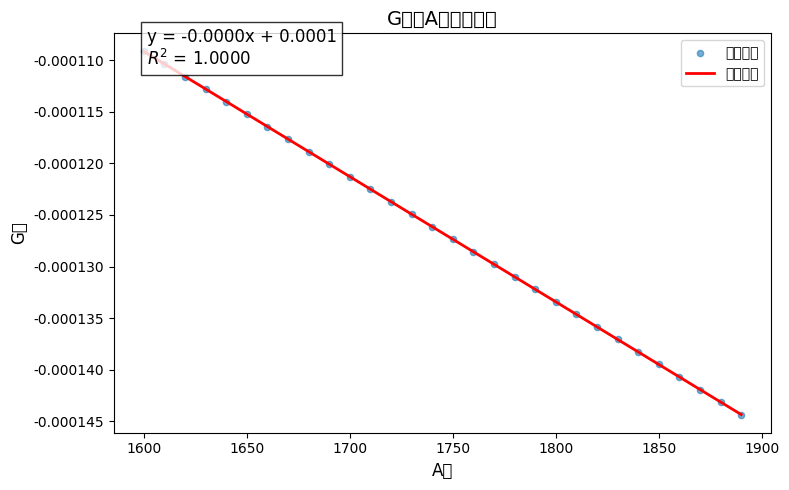

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

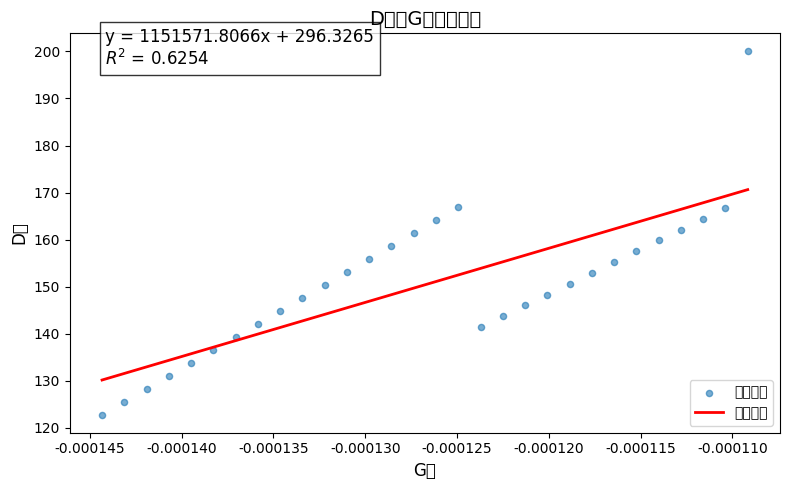

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel('x1.xlsx', sheet_name='Sheet13', usecols="A,D,G").dropna()

# 通用配置
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False    # 显示负号

def plot_fit(x, y, xlabel, ylabel, title):
    """通用拟合绘图函数"""
    coeff = np.polyfit(x, y, 1)
    poly = np.poly1d(coeff)
    y_pred = poly(x)
    
    # 计算R²
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # 绘图
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=20, alpha=0.6, label='原始数据')
    plt.plot(x, y_pred, 'r-', lw=2, label='拟合曲线')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    
    # 添加方程和R²
    equation = f'y = {coeff[0]:.4f}x + {coeff[1]:.4f}'
    text = f'{equation}\n$R^2$ = {r_squared:.4f}'
    plt.text(0.05, 0.92, text, transform=plt.gca().transAxes,
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    plt.legend()
    plt.tight_layout()
    plt.show()

# 绘制G列随A列变化
plot_fit(df.iloc[:, 0], df.iloc[:, 2], 
        xlabel='A列', ylabel='G列', 
        title='G列随A列变化关系')

# 绘制D列随G列变化
plot_fit(df.iloc[:, 2], df.iloc[:, 1], 
        xlabel='G列', ylabel='D列', 
        title='D列随G列变化关系')

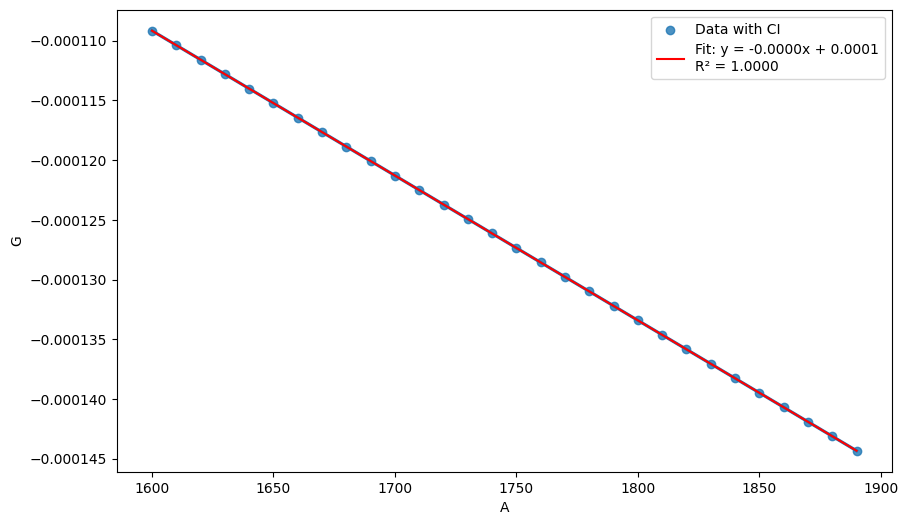

Linear Equation: y = -0.0000x + 0.0001
R-squared Value: 1.0000


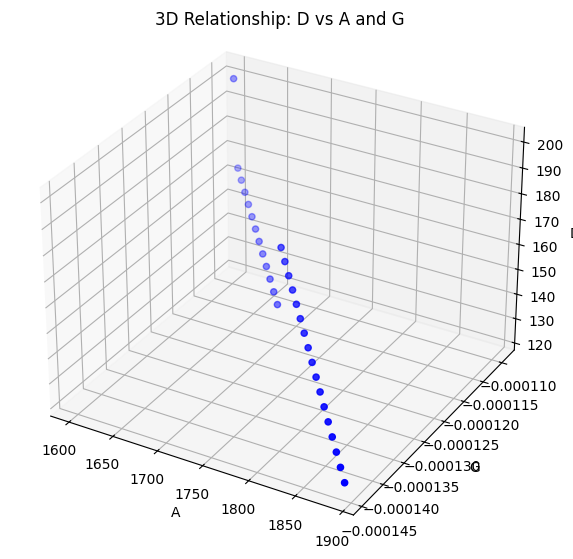

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D

# 读取数据
df = pd.read_excel('x1.xlsx', sheet_name='Sheet13', usecols='A,D,G').dropna()

# 第一部分：G vs A 的拟合与绘图
plt.figure(figsize=(10, 6))
sns.regplot(x='A', y='G', data=df, ci=95, label='Data with CI')

# 计算线性回归参数和R²
x = df['A'].values
y = df['G'].values
coefficients = np.polyfit(x, y, 1)
poly = np.poly1d(coefficients)
r_squared = r2_score(y, poly(x))

# 添加方程和R²到图例
equation = f'y = {coefficients[0]:.4f}x + {coefficients[1]:.4f}'
plt.plot(x, poly(x), color='red', label=f'Fit: {equation}\nR² = {r_squared:.4f}')

plt.xlabel('A')
plt.ylabel('G')
plt.legend(loc='best')
plt.savefig('G_vs_A.png', dpi=300)
plt.show()

# 输出方程和R²
print(f"Linear Equation: {equation}")
print(f"R-squared Value: {r_squared:.4f}")

# 第二部分：D vs G&A 的三维图
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['A'], df['G'], df['D'], c='b', marker='o')

ax.set_xlabel('A')
ax.set_ylabel('G')
ax.set_zlabel('D')
plt.title('3D Relationship: D vs A and G', y=1.04)
plt.savefig('D_vs_AG.png', dpi=300, bbox_inches='tight')
plt.show()

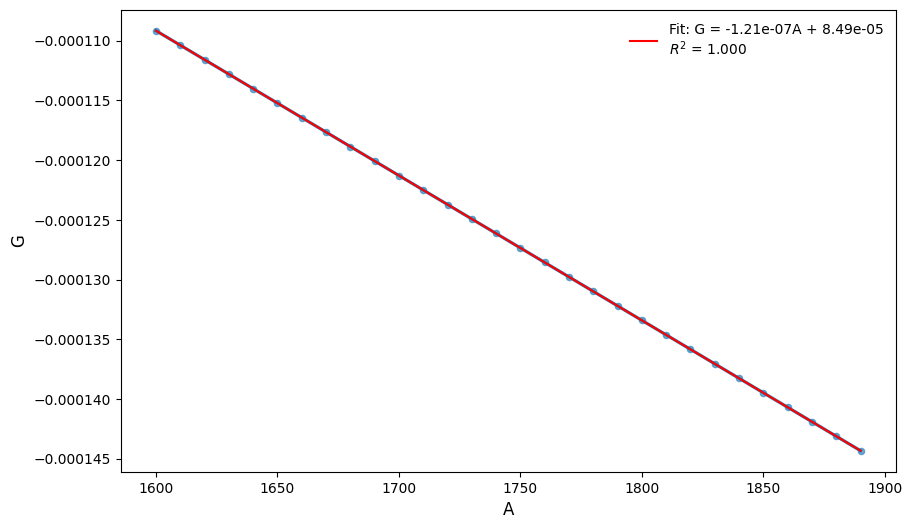

Linear Equation: G = -1.21e-07A + 8.49e-05
R-squared: 1.000


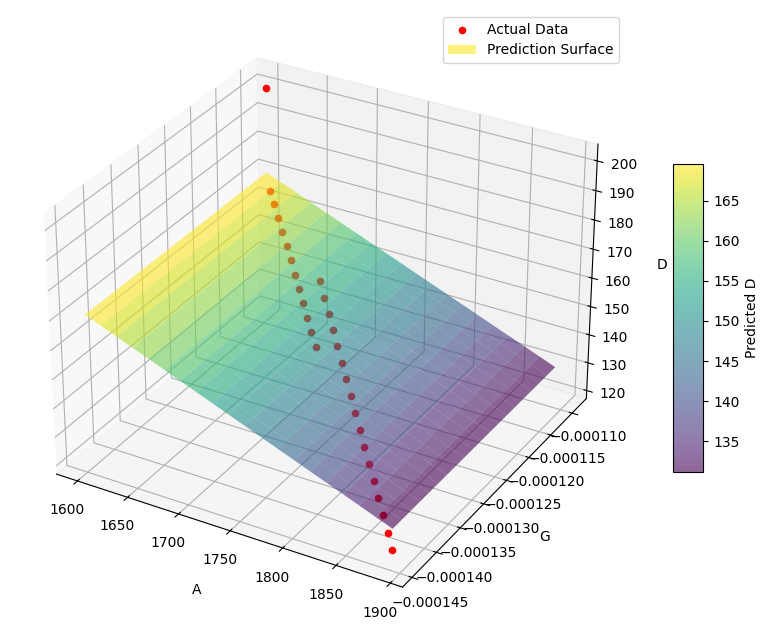

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D

# 读取数据
df = pd.read_excel('x1.xlsx', sheet_name='Sheet13', usecols='A,D,G').dropna()

# ==============================
# 第一部分：G vs A 的线性拟合
# ==============================
plt.figure(figsize=(10, 6))
ax = sns.regplot(x='A', y='G', data=df, ci=95, scatter_kws={'s': 20, 'alpha': 0.6})

# 计算回归参数（保留3位有效数字）
x = df['A'].values.reshape(-1, 1)
y = df['G'].values
model = LinearRegression().fit(x, y)
slope = float(f"{model.coef_[0]:.3g}")  # 格式化有效数字
intercept = float(f"{model.intercept_:.3g}")
r_squared = r2_score(y, model.predict(x))

# 添加拟合线标签
equation = f'G = {slope:.3g}A + {intercept:.3g}'
ax.plot(x, model.predict(x), color='r', 
        label=f'Fit: {equation}\n$R^2$ = {r_squared:.3f}')

plt.xlabel('A', fontsize=12)
plt.ylabel('G', fontsize=12)
plt.legend(loc='best', frameon=False)
plt.savefig('G_vs_A.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Linear Equation: {equation}")
print(f"R-squared: {r_squared:.3f}")

# ==============================
# 第二部分：D vs A&G 三维预测图
# ==============================
# 准备数据矩阵
X = df[['A', 'G']].values
y_d = df['D'].values

# 训练三维回归模型
reg_3d = LinearRegression().fit(X, y_d)

# 生成预测网格
a_grid = np.linspace(X[:,0].min(), X[:,0].max(), 20)
g_grid = np.linspace(X[:,1].min(), X[:,1].max(), 20)
A, G = np.meshgrid(a_grid, g_grid)
D_pred = reg_3d.predict(np.c_[A.ravel(), G.ravel()]).reshape(A.shape)

# 创建三维图
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制原始数据点
scatter = ax.scatter(X[:,0], X[:,1], y_d, c='r', marker='o', 
                    label='Actual Data', depthshade=False)

# 绘制预测曲面
surf = ax.plot_surface(A, G, D_pred, cmap='viridis', alpha=0.6,
                      label='Prediction Surface')

# 图形装饰
ax.set_xlabel('A', labelpad=10)
ax.set_ylabel('G', labelpad=10)
ax.set_zlabel('D', labelpad=10)
ax.legend()
fig.colorbar(surf, shrink=0.5, aspect=10, label='Predicted D')
plt.savefig('D_vs_AG_prediction.png', dpi=300, bbox_inches='tight')
plt.show()
